## sMoE U-Net — Notebook : Dated: 9/7/2026

## Cell 1 — Runtime Check

In [1]:
import torch, sys
print('Python:', sys.version)
print('Torch :', torch.__version__)
print('CUDA  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU   :', torch.cuda.get_device_name(0))
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch : 2.10.0+cu128
CUDA  : True
GPU   : Tesla T4
VRAM  : 15.6 GB
Device: cuda


## Cell 2 — Install Dependencies

In [2]:
!pip install -q numpy matplotlib opencv-python-headless scipy Pillow tqdm scikit-learn
print('Dependencies installed')

Dependencies installed


## Cell 3 — Imports & Configuration

In [3]:
import os, warnings, random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cv2
from tqdm import tqdm
import scipy.io
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torchvision.transforms as T
from sklearn.metrics import precision_recall_curve, auc, average_precision_score

warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paper §3.1 — faithful hyperparameters (UNCHANGED) ─────────────────────────
BATCH_SIZE    = 4        # paper: batch = 4
LEARNING_RATE = 1e-4     # paper: lr = 1e-4
LAMBDA_DICE   = 0.5      # paper Eq.(2): λ = 0.5
N_RULES       = 4        # paper §2.2: R = 4 rules
BASE_CH       = 64       # paper: base channels = 64

# ── Improved training settings (pipeline only, no architecture change) ─────────
MAX_EPOCHS     = 250      # more time for low-LR TSK fine-tuning
PATIENCE       = 25       # TSK MF params converge slowly

# ── Distillation — paper §3.2 does not specify λ_distill ──────────────────────
LAMBDA_DISTILL_START = 0.05
LAMBDA_DISTILL_PEAK  = 0.3
WARMUP_EPOCHS        = 50

def get_lambda_distill(epoch):
    """Linear warm-up of distillation weight from START to PEAK over WARMUP_EPOCHS."""
    if epoch >= WARMUP_EPOCHS:
        return LAMBDA_DISTILL_PEAK
    t = epoch / WARMUP_EPOCHS
    return LAMBDA_DISTILL_START + t * (LAMBDA_DISTILL_PEAK - LAMBDA_DISTILL_START)

# ── MF stability fixes (NEW, additive — does not touch anything above) ────────
# Addresses TSK MF visualisation collapse: sigma->0 (near-delta rules) and
# center drifting outside the valid [0,1] input domain (see Cell 19 diagnostic).
SIGMA_FLOOR       = 0.05   # hard floor on every Gaussian MF's sigma
SIGMA_CEILING     = 0.60   # NEW: hard ceiling — domain is [0,1], so sigma > ~0.6
                           # makes a Gaussian MF nearly flat/uninformative across
                           # the whole input range (observed: sigma drifted to 1.8-2.1
                           # after the floor fix alone — see Cell 19 diagnostic)
SIGMA_TARGET      = 0.30   # NEW: soft target for the two-sided diversity regularizer
MF_LR_MULTIPLIER  = 2.0    # was 5x — reduced to slow the collapse mechanism
LAMBDA_REG_MF     = 1e-3   # weight for the MF diversity/anti-collapse regularizer

# ── Evaluation / data settings ─────────────────────────────────────────────────
CROP_SIZE             = 320
TILE_SIZE             = CROP_SIZE
TILE_STRIDE           = CROP_SIZE // 2
PAD_MULTIPLE          = 16
EDGE_CROP_PROB        = 0.30
SCALE_RANGE           = (0.6, 1.8)
EVAL_FULL_IMAGE_FIRST = True

WORK_DIR  = '/kaggle/working/smoe_results_improved'
BSR_ROOT  = '/kaggle/working/BSR/BSDS500'
os.makedirs(WORK_DIR, exist_ok=True)

# ── Checkpoint settings (NEW) ─────────────────────────────────────────────────
CKPT_DIR    = f'{WORK_DIR}/checkpoints'
MODEL_PATH  = f'{WORK_DIR}/best_model.pth'
CKPT_EVERY  = 25       # save full checkpoint every 25 epochs
KEEP_LAST_N = 3        # keep only last N periodic checkpoints (disk saving)
# Set this after publishing checkpoints as a Kaggle Dataset (leave '' on first run):
PREV_CKPT_INPUT = ''   # e.g. '/kaggle/input/smoe-checkpoints/checkpoints'

os.makedirs(CKPT_DIR, exist_ok=True)

print(f'Paper hyperparameters : batch={BATCH_SIZE} | lr={LEARNING_RATE} | λ_dice={LAMBDA_DICE}')
print(f'Architecture          : base_ch={BASE_CH}  | n_rules={N_RULES}')
print(f'Training              : MAX_EPOCHS={MAX_EPOCHS} | PATIENCE={PATIENCE}')
print(f'Distillation warm-up  : λ_distill {LAMBDA_DISTILL_START}→{LAMBDA_DISTILL_PEAK} over {WARMUP_EPOCHS} epochs')
print(f'EDGE_CROP_PROB        : {EDGE_CROP_PROB}')
print(f'SCALE_RANGE           : {SCALE_RANGE}')
print(f'Checkpoint every      : {CKPT_EVERY} epochs  keep_last={KEEP_LAST_N}')
print(f'MF stability fixes  : sigma_bounds=[{SIGMA_FLOOR},{SIGMA_CEILING}] | MF_lr_mult={MF_LR_MULTIPLIER}x | lambda_reg_mf={LAMBDA_REG_MF} | sigma_target={SIGMA_TARGET}')
print('Config ready')


Paper hyperparameters : batch=4 | lr=0.0001 | λ_dice=0.5
Architecture          : base_ch=64  | n_rules=4
Training              : MAX_EPOCHS=250 | PATIENCE=25
Distillation warm-up  : λ_distill 0.05→0.3 over 50 epochs
EDGE_CROP_PROB        : 0.3
SCALE_RANGE           : (0.6, 1.8)
Checkpoint every      : 25 epochs  keep_last=3
MF stability fixes  : sigma_bounds=[0.05,0.6] | MF_lr_mult=2.0x | lambda_reg_mf=0.001 | sigma_target=0.3
Config ready


## Cell 4 — Download BSDS500

In [4]:
import tarfile

BSR_TGZ = '/kaggle/working/BSR_bsds500.tgz'
BSR_DIR  = '/kaggle/working/BSR'

if not os.path.exists(os.path.join(BSR_DIR, 'BSDS500', 'data', 'images', 'train')):
    print('Downloading BSDS500...')
    os.system(f'wget -q --show-progress '
              f'https://www2.eecs.berkeley.edu/Research/Projects/CS/vision/grouping/BSR/BSR_bsds500.tgz '
              f'-O {BSR_TGZ}')
    with tarfile.open(BSR_TGZ, 'r:gz') as tar:
        tar.extractall('/kaggle/working/')
    print('Extracted.')
else:
    print('BSDS500 already present.')

for split in ['train', 'val', 'test']:
    n_img = len([f for f in os.listdir(f'{BSR_DIR}/BSDS500/data/images/{split}') if f.endswith('.jpg')])
    n_gt  = len([f for f in os.listdir(f'{BSR_DIR}/BSDS500/data/groundTruth/{split}') if f.endswith('.mat')])
    print(f'  [{split:>5}]  images={n_img}  gt_mats={n_gt}')

BSR_ROOT = f'{BSR_DIR}/BSDS500'
print('Dataset ready')


     0K .......... .......... .......... .......... ..........  0%  707K 98s
    50K .......... .......... .......... .......... ..........  0%  738K 96s
   100K .......... .......... .......... .......... ..........  0%  766K 94s
   150K .......... .......... .......... .......... ..........  0% 17.2M 71s
   200K .......... .......... .......... .......... ..........  0% 1.71M 65s
   250K .......... .......... .......... .......... ..........  0% 1.32M 62s
   300K .......... .......... .......... .......... ..........  0%  174M 53s
   350K .......... .......... .......... .......... ..........  0% 24.3M 47s
   400K .......... .......... .......... .......... ..........  0%  142M 42s
   450K .......... .......... .......... .......... ..........  0% 1.72M 42s
   500K .......... .......... .......... .......... ..........  0% 1.34M 42s
   550K .......... .......... .......... .......... ..........  0% 77.0M 39s
   600K .......... .......... .......... .......... ..........  0%  204M 36

Extracted.
  [train]  images=200  gt_mats=200
  [  val]  images=100  gt_mats=100
  [ test]  images=200  gt_mats=200
Dataset ready


## Cell 5 — Sobel Edge Detector

In [5]:
class SobelEdgeDetector(nn.Module):
    """Paper §2.1 — fixed Sobel filter, output in [0,1].
    Expects RGB in [0,1] — caller must denormalise before passing.
    Bug fix 1: reflect-padding avoids artificial border-edge artefacts.
    UNCHANGED from base notebook — architecture faithful.
    """
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]],  dtype=torch.float32)
        self.register_buffer('kx', kx.view(1,1,3,3))
        self.register_buffer('ky', ky.view(1,1,3,3))

    def forward(self, x):
        gray = 0.2126*x[:,0:1] + 0.7152*x[:,1:2] + 0.0722*x[:,2:3]
        gray = F.pad(gray, (1,1,1,1), mode='reflect')
        gx   = F.conv2d(gray, self.kx, padding=0)
        gy   = F.conv2d(gray, self.ky, padding=0)
        mag  = torch.sqrt(gx**2 + gy**2 + 1e-8)
        B    = mag.shape[0]
        flat = mag.view(B, -1)
        mn   = flat.min(1, keepdim=True)[0].view(B,1,1,1)
        mx   = flat.max(1, keepdim=True)[0].view(B,1,1,1)
        return (mag - mn) / (mx - mn + 1e-8)

print('SobelEdgeDetector defined — paper §2.1 faithful')

SobelEdgeDetector defined — paper §2.1 faithful


## Cell 6 — sMoE Block 

In [6]:
class sMoEBlock(nn.Module):
    """Paper §2.1 Eq.(1) — exact paper architecture. UNCHANGED from base notebook.
    Y = G(E)·Expert_sharp(X) + (1-G(E))·Expert_smooth(X)
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.context_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=2, dilation=2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.boundary_expert = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.gate = nn.Sequential(
            nn.Conv2d(1, 1, 1),
            nn.Sigmoid(),
        )

    def forward(self, x, edge_signal):
        e = F.interpolate(edge_signal, size=x.shape[-2:],
                          mode='bilinear', align_corners=False)
        g      = self.gate(e)
        sharp  = self.boundary_expert(x)
        smooth = self.context_expert(x)
        y      = g * sharp + (1.0 - g) * smooth   # Paper Eq.(1)
        return y, g

print('sMoEBlock defined — paper §2.1 faithful, UNCHANGED')

sMoEBlock defined — paper §2.1 faithful, UNCHANGED


## Cell 7 — TSK Fuzzy Head

In [7]:
import math

class GaussianMF(nn.Module):
    """Learnable Gaussian membership function — paper §2.2.

    MF STABILITY FIX (NEW, additive on top of the paper-faithful formulation):
    fixes the MF collapse diagnosed from the Cell 19 visualisation (sigma -> ~0
    "delta spikes" on R1/R2, center drifting to 1.035 — outside the valid
    domain). Two changes, both purely reparameterisations (no new architecture,
    no change to what the MF represents):

      1. Sigma floor: sigma is clamped to >= SIGMA_FLOOR on every forward call,
         so a rule can never collapse into a near-Dirac spike and stop being
         genuinely "fuzzy".
      2. Center reparameterisation: center is stored as an unconstrained
         `center_raw` and passed through sigmoid() to get the effective center,
         which is then mathematically guaranteed to stay in (0,1) — matching
         the true domain of x1 (normalised Sobel) and x2 (sigmoid semantic
         confidence). Gradient descent can no longer push it out of range.
      3. Sigma ceiling (NEW, additive on top of the floor): sigma is ALSO
         clamped to <= SIGMA_CEILING. The floor-only fix (1) stopped the
         sigma->0 collapse, but on the following training run sigma instead
         drifted up to 1.8-2.1 (near-flat, uninformative MFs over the [0,1]
         domain) — the mf_diversity_regularizer() below only penalised sigma
         being too SMALL, so nothing stopped it from growing unbounded. This
         two-sided clamp closes that gap without touching anything else.
    """
    def __init__(self, init_center: float, init_sigma: float = 0.35):  # Suggestion 2: was 0.25 — wider init MFs for stronger early firing
        super().__init__()
        # Reparameterise center as a logit so sigmoid(center_raw) == init_center at init.
        _c0 = min(max(init_center, 1e-4), 1 - 1e-4)
        _center_raw_init = math.log(_c0 / (1 - _c0))
        self.center_raw = nn.Parameter(torch.tensor(_center_raw_init, dtype=torch.float32))
        self.sigma       = nn.Parameter(torch.tensor(init_sigma,      dtype=torch.float32))

    @property
    def center(self):
        """Effective center — always in (0,1). MF STABILITY FIX."""
        return torch.sigmoid(self.center_raw)

    @property
    def sigma_floored(self):
        """Effective sigma — bounded to [SIGMA_FLOOR, SIGMA_CEILING]. Never collapses
        to 0 (delta spike) and never balloons past SIGMA_CEILING (near-flat MF).
        Name kept as `sigma_floored` (not renamed) so nothing downstream that
        already references it needs to change."""
        return self.sigma.abs().clamp(min=SIGMA_FLOOR, max=SIGMA_CEILING)

    def forward(self, x):
        return torch.exp(-((x - self.center)**2) /
                         (2 * self.sigma_floored**2 + 1e-8))


class TSKRule(nn.Module):
    """First-order TSK rule — paper §2.2. UNCHANGED."""
    def __init__(self, cx1: float, cx2: float, init_r: float):
        super().__init__()
        self.mf_x1 = GaussianMF(cx1)
        self.mf_x2 = GaussianMF(cx2)
        self.r = nn.Parameter(torch.tensor(init_r, dtype=torch.float32))
        self.p = nn.Parameter(torch.tensor(0.05,   dtype=torch.float32))
        self.q = nn.Parameter(torch.tensor(0.05,   dtype=torch.float32))

    def forward(self, x1, x2):
        w = self.mf_x1(x1) * self.mf_x2(x2)
        c = self.r + self.p * x1 + self.q * x2
        return w, c


class TSKFuzzyHead(nn.Module):
    """Paper §2.2 — 4 first-order TSK rules, Gaussian MFs, CoG defuzzification.

    PAPER-ALIGNMENT FIX (was BF3, now reverted): the paper states its network
    "terminates in a differentiable TSK fuzzy inference engine" and explicitly
    contrasts this with "standard neural networks that end in a sigmoid
    activation" — i.e. NO final sigmoid layer. The previous version added one
    anyway (to make the raw CoG output well-posed for plain BCE). That sigmoid
    has now been REMOVED from the architecture to match the paper exactly.
    forward() returns the raw CoG weighted average — unbounded, logit-like.

    Consequence (handled at the call sites, not here): anything that needs a
    probability (BCE, Dice, visualisation, evaluation) now applies
    torch.sigmoid() itself where needed — exactly the same pattern as
    PyTorch's own BCEWithLogitsLoss (model outputs logits; sigmoid lives in
    the loss/metric code, not in the network). See Cell 10, Cell 10b, Cell 12,
    Cell 11b for where that sigmoid is now applied downstream.

    ISSUE-2 FIX (unchanged): return_logit flag removed entirely — the model
    now has exactly one return convention (raw CoG) everywhere, so no flag
    is needed to switch between logit/probability modes.
    """
    def __init__(self, in_ch: int, n_rules: int = 4):
        super().__init__()
        self.n_rules = n_rules
        self.semantic_conv = nn.Sequential(
            nn.Conv2d(in_ch, 16, 1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, 1),
        )
        rule_defs = [
            (0.8, 0.8, 0.9),   # R1: strong edge + high semantic → boundary
            (0.2, 0.8, 0.7),   # R2: weak  edge + high semantic → semantic edge
            (0.2, 0.2, 0.1),   # R3: weak  edge + low  semantic → background
            (0.8, 0.2, 0.2),   # R4: strong edge + low  semantic → texture/FP
        ]
        self.rules = nn.ModuleList([TSKRule(cx1, cx2, r) for cx1, cx2, r in rule_defs])

    def mf_diversity_regularizer(self):
        """MF STABILITY FIX (UPDATED — now two-sided, was one-sided).

        Original version only penalised sigma sitting near SIGMA_FLOOR
        (reg = sum(1/sigma)), which discourages collapse-to-delta but has
        NO term discouraging sigma from growing arbitrarily large — that
        is exactly what happened on the next training run (sigma drifted
        to ~1.8-2.1, i.e. near-flat MFs over the [0,1] domain).

        Now: reg = sum(1/sigma) + sum((sigma - SIGMA_TARGET)^2)
          - the 1/sigma term still discourages collapse toward the floor
          - the new quadratic term pulls sigma back toward SIGMA_TARGET
            (0.30 by default) whenever it drifts too high, without a hard
            cutoff — the hard cutoff is the SIGMA_CEILING clamp above;
            this term is what stops it drifting there in the first place.
        Multiply by LAMBDA_REG_MF and add to the total loss in the training
        loop — does not touch the forward pass or predictions at all.
        """
        reg = 0.0
        for rule in self.rules:
            for mf in (rule.mf_x1, rule.mf_x2):
                s = mf.sigma_floored
                reg = reg + 1.0 / s + (s - SIGMA_TARGET)**2
        return reg

    def forward(self, features, edge_signal):
        """Returns the RAW CoG weighted average — no final sigmoid (paper-faithful).

        Args:
            features:    [B, C, H, W] decoder output
            edge_signal: [B, 1, H, W] Sobel map
        Returns:
            output:     [B, H, W]   raw CoG — unbounded, logit-like (NOT a probability)
            rule_maps:  [B, R, H, W] firing strengths per rule
            x2:         [B, 1, H, W] semantic confidence map
        """
        x1 = F.interpolate(edge_signal, size=features.shape[-2:],
                           mode='bilinear', align_corners=False)
        x2 = torch.sigmoid(self.semantic_conv(features))   # paper: sigmoid(semantic)

        firings, consequents = [], []
        for rule in self.rules:
            w, c = rule(x1, x2)
            firings.append(w)
            consequents.append(c)

        W = torch.stack(firings,     dim=1)   # [B,R,1,H,W]
        C = torch.stack(consequents, dim=1)   # [B,R,1,H,W]

        W_sum = W.sum(dim=1, keepdim=True).clamp(min=1e-8)
        cog   = (W * C).sum(dim=1, keepdim=True) / W_sum   # CoG defuzzification

        # PAPER-ALIGNMENT FIX: no sigmoid here anymore. Raw CoG is the output,
        # exactly as the paper describes ("terminates in a ... fuzzy inference
        # engine", not a sigmoid). Downstream code applies sigmoid where a
        # probability is actually needed (loss, evaluation, display).
        output = cog.squeeze(1)                             # [B,H,W] — raw, unbounded

        rule_maps = W[:, :, 0]                              # [B,R,H,W]
        return output, rule_maps, x2


print('TSKFuzzyHead defined — paper §2.2 faithful')
print('  init_sigma=0.35 (Suggestion 2: wider MFs for stronger early firing, was 0.25)')
print('  PAPER-ALIGNMENT FIX: sigmoid REMOVED from forward() — raw CoG output, no final')
print('  activation, matching the paper ("terminates in ... fuzzy inference engine")')
print('  Rule centres: R1(0.8,0.8) R2(0.2,0.8) R3(0.2,0.2) R4(0.8,0.2) — paper §2.2')
print(f'  MF STABILITY FIX: sigma bounded to [{SIGMA_FLOOR}, {SIGMA_CEILING}] | center reparam via sigmoid -> always in (0,1)')
print(f'  MF STABILITY FIX: mf_diversity_regularizer() is now two-sided (1/sigma + (sigma-{SIGMA_TARGET})^2)')


TSKFuzzyHead defined — paper §2.2 faithful
  init_sigma=0.35 (Suggestion 2: wider MFs for stronger early firing, was 0.25)
  PAPER-ALIGNMENT FIX: sigmoid REMOVED from forward() — raw CoG output, no final
  activation, matching the paper ("terminates in ... fuzzy inference engine")
  Rule centres: R1(0.8,0.8) R2(0.2,0.8) R3(0.2,0.2) R4(0.8,0.2) — paper §2.2
  MF STABILITY FIX: sigma bounded to [0.05, 0.6] | center reparam via sigmoid -> always in (0,1)
  MF STABILITY FIX: mf_diversity_regularizer() is now two-sided (1/sigma + (sigma-0.3)^2)


## Cell 8 — Full sMoE U-Net 

In [8]:
class DoubleConv(nn.Module):
    """Standard U-Net double convolution block. UNCHANGED — paper Fig. 1."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class sMoEUNet(nn.Module):
    """Paper Fig. 1 — exact architecture.
    Bug fixes retained: (1) Sobel denorm, (2) reflect padding.
    PAPER-ALIGNMENT FIX: sigmoid removed from the TSK head's output — the model's
    forward() now returns the raw CoG value (unbounded, logit-like), matching the
    paper's stated "no final sigmoid" design. Sigmoid is applied only at the
    downstream call sites that actually need a probability (loss, eval, display).
    Issue-2 fix: forward() no longer accepts return_logit (single return convention).
    ARCHITECTURE UNCHANGED otherwise.
    """
    def __init__(self, base_ch: int = 64, n_rules: int = 4):
        super().__init__()
        c = base_ch
        self.sobel = SobelEdgeDetector()

        self.register_buffer('img_mean',
            torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('img_std',
            torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        # Encoder
        self.enc1 = DoubleConv(3,   c)
        self.enc2 = DoubleConv(c,   c*2)
        self.enc3 = DoubleConv(c*2, c*4)
        self.enc4 = DoubleConv(c*4, c*8)
        self.bot  = DoubleConv(c*8, c*16)
        self.pool = nn.MaxPool2d(2)

        # sMoE blocks on all 4 skip connections — paper Fig. 1
        self.smoe1 = sMoEBlock(c,   c)
        self.smoe2 = sMoEBlock(c*2, c*2)
        self.smoe3 = sMoEBlock(c*4, c*4)
        self.smoe4 = sMoEBlock(c*8, c*8)

        # Decoder
        self.up4  = nn.ConvTranspose2d(c*16, c*8,  2, stride=2)
        self.dec4 = DoubleConv(c*16, c*8)
        self.up3  = nn.ConvTranspose2d(c*8,  c*4,  2, stride=2)
        self.dec3 = DoubleConv(c*8,  c*4)
        self.up2  = nn.ConvTranspose2d(c*4,  c*2,  2, stride=2)
        self.dec2 = DoubleConv(c*4,  c*2)
        self.up1  = nn.ConvTranspose2d(c*2,  c,    2, stride=2)
        self.dec1 = DoubleConv(c*2,  c)

        # TSK Fuzzy Head — paper §2.2
        self.tsk_head = TSKFuzzyHead(c, n_rules)

        # MSE Distillation head (Paper §3.2 — ADDED)
        # Standard 1×1 conv producing U-Net logits from decoder output d1.
        # During training, TSK output is trained to mimic sigmoid(unet_logits).
        self.unet_head = nn.Conv2d(c, 1, 1)

    def forward(self, x):
        """Returns 5-tuple:
            logit       [B, H, W]    — TSK raw CoG output (unbounded, NOT a probability
                                        anymore — PAPER-ALIGNMENT FIX, sigmoid removed)
            rule_maps   [B, R, H, W] — per-rule firing strengths
            x2          [B, 1, H, W] — semantic confidence map
            edge        [B, 1, H, W] — Sobel edge signal
            unet_logits [B, 1, H, W] — U-Net head raw logits (for MSE distillation)
        """
        # Bug fix 2: denormalise to RGB ∈ [0,1] before Sobel
        x_raw = (x * self.img_std + self.img_mean).clamp(0, 1)
        edge  = self.sobel(x_raw)

        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b  = self.bot(self.pool(e4))

        s1, g1 = self.smoe1(e1, edge)
        s2, g2 = self.smoe2(e2, edge)
        s3, g3 = self.smoe3(e3, edge)
        s4, g4 = self.smoe4(e4, edge)

        d4 = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], dim=1))

        # MSE Distillation head: produce U-Net logits from d1 (Paper §3.2)
        unet_logits = self.unet_head(d1)           # [B,1,H,W] raw logits

        # TSK head: returns raw CoG logit (no sigmoid, no return_logit flag)
        logit, rule_maps, x2 = self.tsk_head(d1, edge)
        return logit, rule_maps, x2, edge, unet_logits


print('sMoEUNet defined — paper Fig.1 faithful + MSE distillation head added')
print('  PAPER-ALIGNMENT FIX: forward() returns (logit, rule_maps, x2, edge, unet_logits)')
print('  logit is now the RAW CoG output — no sigmoid layer in the model anymore')
_m = sMoEUNet(base_ch=64, n_rules=4)
_x = torch.zeros(1, 3, 64, 64)
_out = _m(_x)
print(f'  Smoke test: logit={_out[0].shape}, rule_maps={_out[1].shape}, '
      f'x2={_out[2].shape}, edge={_out[3].shape}, unet_logits={_out[4].shape}')
print(f'  Smoke test logit range: [{_out[0].min().item():.3f}, {_out[0].max().item():.3f}] '
      f'(expected: NOT bounded to [0,1] anymore)')
del _m, _x, _out


sMoEUNet defined — paper Fig.1 faithful + MSE distillation head added
  PAPER-ALIGNMENT FIX: forward() returns (logit, rule_maps, x2, edge, unet_logits)
  logit is now the RAW CoG output — no sigmoid layer in the model anymore
  Smoke test: logit=torch.Size([1, 1, 64, 64]), rule_maps=torch.Size([1, 4, 64, 64]), x2=torch.Size([1, 1, 64, 64]), edge=torch.Size([1, 1, 64, 64]), unet_logits=torch.Size([1, 1, 64, 64])
  Smoke test logit range: [0.175, 0.559] (expected: NOT bounded to [0,1] anymore)


## Cell 9 — BSDS500 Dataset

In [9]:
def load_gt(mat_path):
    mat    = scipy.io.loadmat(mat_path)
    cells  = mat['groundTruth'][0]
    bounds = [cells[i]['Boundaries'][0,0].astype(np.float32)
              for i in range(len(cells))]
    soft   = np.mean(bounds, axis=0)
    binary = (soft > 0).astype(np.float32)
    return soft, binary


class BSDS500Dataset(Dataset):
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    def __init__(self, img_dir, gt_dir, mode='train',
                 crop_size=320, soft_labels=True,
                 edge_crop_prob=0.30, scale_range=(0.7, 1.5)):
        self.mode           = mode
        self.crop_size      = crop_size
        self.soft           = soft_labels
        self.edge_crop_prob = edge_crop_prob
        self.scale_range    = scale_range
        self.norm           = T.Normalize(mean=self.MEAN, std=self.STD)
        self.samples        = []
        for fname in sorted(os.listdir(img_dir)):
            if not fname.endswith('.jpg'): continue
            stem   = fname.replace('.jpg', '')
            gt_pth = os.path.join(gt_dir, stem + '.mat')
            if os.path.exists(gt_pth):
                self.samples.append((os.path.join(img_dir, fname), gt_pth, stem))
        print(f'  {len(self.samples)} samples [{mode}]')

    def __len__(self): return len(self.samples)

    def _pad_if_needed(self, ip, mp):
        w, h  = ip.size
        pw    = max(self.crop_size - w, 0)
        ph    = max(self.crop_size - h, 0)
        if pw > 0 or ph > 0:
            ip = TF.pad(ip, [0,0,pw,ph], fill=0)
            mp = TF.pad(mp, [0,0,pw,ph], fill=0)
        return ip, mp

    def _crop(self, ip, mp):
        ip, mp = self._pad_if_needed(ip, mp)
        w, h   = ip.size
        cs     = self.crop_size
        mn     = np.array(mp)
        if random.random() < self.edge_crop_prob and np.any(mn > 0):
            ys, xs = np.where(mn > 0)
            k      = random.randint(0, len(xs)-1)
            cy, cx = int(ys[k]), int(xs[k])
            top    = int(np.clip(cy - cs//2, 0, h - cs))
            left   = int(np.clip(cx - cs//2, 0, w - cs))
        else:
            top  = random.randint(0, h - cs)
            left = random.randint(0, w - cs)
        return TF.crop(ip, top, left, cs, cs), TF.crop(mp, top, left, cs, cs)

    def _train_transform(self, ip, mp):
        # IMPROVED: uses self.scale_range (passed from SCALE_RANGE = (0.6, 1.8))
        scale = random.uniform(*self.scale_range)
        w, h  = ip.size
        nw    = max(int(w * scale), self.crop_size)
        nh    = max(int(h * scale), self.crop_size)
        ip    = TF.resize(ip, [nh, nw], interpolation=T.InterpolationMode.BILINEAR)
        mp    = TF.resize(mp, [nh, nw], interpolation=T.InterpolationMode.NEAREST)
        if random.random() < 0.5:
            ip = TF.hflip(ip); mp = TF.hflip(mp)
        if random.random() < 0.5:
            ip = TF.vflip(ip); mp = TF.vflip(mp)
        angle = random.choice([0, 90, 180, 270])
        if angle:
            ip = TF.rotate(ip, angle); mp = TF.rotate(mp, angle)
        ip, mp = self._crop(ip, mp)
        ip = T.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05)(ip)
        if random.random() < 0.10:
            ip = TF.to_grayscale(ip, num_output_channels=3)
        return ip, mp

    def __getitem__(self, idx):
        img_path, gt_path, stem = self.samples[idx]
        img_np = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        soft_gt, bin_gt = load_gt(gt_path)
        gt_np  = soft_gt if self.soft else bin_gt
        ip     = Image.fromarray(img_np)
        mp     = Image.fromarray((gt_np * 255).astype(np.uint8), mode='L')
        if self.mode == 'train':
            ip, mp = self._train_transform(ip, mp)
        return self.norm(TF.to_tensor(ip)), TF.to_tensor(mp), stem

print('BSDS500Dataset defined — pipeline improvements applied (scale_range, edge_crop_prob)')

BSDS500Dataset defined — pipeline improvements applied (scale_range, edge_crop_prob)


## Cell 10 — BCEDiceLoss 

In [10]:
class BCEDiceLoss(nn.Module):
    """Paper §3.2 Eq.(2) — faithful implementation.

    L = λ·L_BCE + (1−λ)·L_Dice,  λ = 0.5

    Issue-1 fix: replaces BalancedBCEDiceLoss (which used pos_weight not in paper).
    Operates on PROBABILITIES (not logits). NOTE (post PAPER-ALIGNMENT FIX): the TSK
    head itself no longer applies a sigmoid (Cell 7/8) — the caller (Cell 12's
    train_one_epoch) now applies torch.sigmoid() to the raw CoG output before
    passing it in here, so this class's interface/behaviour is UNCHANGED.
    Dice term provides inherent class-balance for sparse edge pixels.
    Soft GT used for BCE (annotator mean); binary threshold for Dice.

    Args:
        lam:          Dice weight — paper λ = 0.5
        gt_threshold: threshold to binarise soft GT for Dice loss
    """
    def __init__(self, lam: float = 0.5, gt_threshold: float = 0.3):
        super().__init__()
        self.lam          = lam
        self.gt_threshold = gt_threshold

    def _bce(self, p, t):
        """Standard BCE on probabilities with soft GT."""
        p = p.clamp(1e-6, 1 - 1e-6)
        return F.binary_cross_entropy(p, t, reduction='mean')

    def _dice(self, p, t):
        """Soft Dice loss — inherently class-balanced."""
        inter = (p * t).sum(dim=[1, 2, 3])
        union = p.sum(dim=[1, 2, 3]) + t.sum(dim=[1, 2, 3])
        return (1.0 - (2.0 * inter + 1.0) / (union + 1.0)).mean()

    def forward(self, pred, target_soft):
        if pred.dim()        == 3: pred        = pred.unsqueeze(1)
        if target_soft.dim() == 3: target_soft = target_soft.unsqueeze(1)
        # Binarise soft GT for Dice (standard BSDS practice)
        target_bin = (target_soft > self.gt_threshold).float()
        bce  = self._bce(pred, target_soft)    # BCE on soft labels
        dice = self._dice(pred, target_bin)    # Dice on binary labels
        return self.lam * bce + (1.0 - self.lam) * dice


print('BCEDiceLoss defined — paper §3.2 Eq.(2) faithful')
print('  L = 0.5·BCE(prob, soft_gt) + 0.5·Dice(prob, bin_gt)')
print('  No pos_weight, no BCEWithLogits — operates on TSK sigmoid probabilities')

# Sanity check
_pred = torch.full((2, 1, 64, 64), 0.5)   # predict 0.5 everywhere
_gt   = torch.zeros(2, 1, 64, 64)
_gt[:, :, 28:36, 28:36] = 1.0
_loss = BCEDiceLoss()(_pred, _gt)
print(f'  Sanity: loss on 50% prediction, sparse GT = {_loss.item():.4f} (expect ~0.5–0.9)')
del _pred, _gt, _loss


BCEDiceLoss defined — paper §3.2 Eq.(2) faithful
  L = 0.5·BCE(prob, soft_gt) + 0.5·Dice(prob, bin_gt)
  No pos_weight, no BCEWithLogits — operates on TSK sigmoid probabilities
  Sanity: loss on 50% prediction, sparse GT = 0.8312 (expect ~0.5–0.9)


## Cell 10b — MSEDistillationLoss — IMPROVED (warm-up scheduling)

In [11]:
class MSEDistillationLoss(nn.Module):
    """Paper §3.2 — MSE distillation: TSK head is trained to mimic U-Net logits.

    Paper quote: 'For the explainable head, we employ a distillation approach where
    the fuzzy output is trained to mimic the main U-Net logits using MSE loss.'

    PAPER-ALIGNMENT FIX: the paper says "mimic the main U-Net LOGITS" — literally,
    not sigmoid(logits). The previous version compared teacher=sigmoid(unet_logits)
    against a student that was itself a sigmoid-ed probability, which happened to be
    self-consistent but wasn't literally what the paper describes. Now that the TSK
    head's raw CoG output is itself unbounded/logit-like (sigmoid removed, see Cell 7),
    this is not just more faithful — it's now REQUIRED, since comparing an unbounded
    CoG value against a [0,1]-bounded sigmoid(logits) would mix incompatible scales.

    teacher = unet_logits               # U-Net decoder RAW logits (teacher) — no sigmoid
    student = tsk_logit                 # TSK raw CoG output (student) — no sigmoid
    L_distill = MSE(student, teacher)   # pixel-wise MSE, both in raw/unbounded space

    IMPROVED: λ_distill is still a warm-up schedule (0.5 → 1.5 over 100 epochs).
    The current λ is passed per-step from the training loop.
    """
    def forward(self, tsk_logit, unet_logits):
        if tsk_logit.dim() == 3:
            tsk_logit = tsk_logit.unsqueeze(1)
        return F.mse_loss(tsk_logit, unet_logits)   # PAPER-ALIGNMENT FIX: no sigmoid, raw-to-raw


# Current λ_distill — updated each epoch by get_lambda_distill(epoch)
LAMBDA_DISTILL = LAMBDA_DISTILL_START

print('MSEDistillationLoss defined — Paper §3.2 (PAPER-ALIGNMENT FIX: now raw-logit-to-raw-logit, no sigmoid)')
print(f'  λ_distill warm-up: {LAMBDA_DISTILL_START} → {LAMBDA_DISTILL_PEAK} over {WARMUP_EPOCHS} epochs')
print(f'  Epoch 1  λ_distill ≈ {get_lambda_distill(1):.3f}')
print(f'  Epoch 50 λ_distill ≈ {get_lambda_distill(50):.3f}')
print(f'  Epoch 100+ λ_distill = {LAMBDA_DISTILL_PEAK}')

_tsk    = torch.randn(2, 1, 64, 64)   # PAPER-ALIGNMENT FIX: raw logit-like, no sigmoid
_logits = torch.randn(2, 1, 64, 64)
_dl     = MSEDistillationLoss()(_tsk, _logits)
print(f'  Sanity: MSE distillation loss (raw logit vs raw logit) = {_dl.item():.4f} (expect ~1-3, both ~N(0,1))')
del _tsk, _logits, _dl

MSEDistillationLoss defined — Paper §3.2 (PAPER-ALIGNMENT FIX: now raw-logit-to-raw-logit, no sigmoid)
  λ_distill warm-up: 0.05 → 0.3 over 50 epochs
  Epoch 1  λ_distill ≈ 0.055
  Epoch 50 λ_distill ≈ 0.300
  Epoch 100+ λ_distill = 0.3
  Sanity: MSE distillation loss (raw logit vs raw logit) = 2.0466 (expect ~1-3, both ~N(0,1))


## Cell 11 — Build Datasets, DataLoaders, Model, Optimizer

In [12]:
import torch.optim as optim

_img = lambda s: f'{BSR_ROOT}/data/images/{s}'
_gt  = lambda s: f'{BSR_ROOT}/data/groundTruth/{s}'

class BSDS500DatasetLimited(BSDS500Dataset):
    """Wraps BSDS500Dataset with an optional cap on number of training samples."""
    def __init__(self, *args, max_samples=None, **kwargs):
        super().__init__(*args, **kwargs)
        if max_samples is not None and len(self.samples) > max_samples:
            self.samples = self.samples[:max_samples]
            print(f'  Capped to {max_samples} samples [{kwargs.get("mode","train")}]')

print('Building datasets...')
# Paper §3.1: 200 training images — restored from 400 to match paper exactly
ds_train = BSDS500DatasetLimited(
    _img('train'), _gt('train'),
    mode='train', crop_size=CROP_SIZE,
    soft_labels=True,
    edge_crop_prob=EDGE_CROP_PROB,
    scale_range=SCALE_RANGE,
    max_samples=200                   # paper §3.1: 200 training images
)
ds_val  = BSDS500Dataset(_img('val'),  _gt('val'),  mode='val',  soft_labels=True)
ds_test = BSDS500Dataset(_img('test'), _gt('test'), mode='test', soft_labels=False)

loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
loader_val   = DataLoader(ds_val,  batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)
loader_test  = DataLoader(ds_test, batch_size=1, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'  Train : {len(ds_train)} images ({len(loader_train)} batches/epoch)')
print(f'  Val   : {len(ds_val)} images')
print(f'  Test  : {len(ds_test)} images')

model = sMoEUNet(base_ch=BASE_CH, n_rules=N_RULES).to(DEVICE)

# Paper-faithful losses
criterion         = BCEDiceLoss(lam=LAMBDA_DICE, gt_threshold=0.3)  # 0.3 — REVERTED/CORRECT
distill_criterion = MSEDistillationLoss()

# Suggestion 1: param-group Adam — MF params get a higher LR for faster convergence.
# MF STABILITY FIX (NEW): multiplier reduced from 5x -> MF_LR_MULTIPLIER (2x, see Cell 3
# config). The 5x multiplier was identified as a key accelerant of the sigma-collapse /
# center-drift seen in the Cell 19 diagnostic — a faster MF learning rate combined with
# an unconstrained sigma let some rules shrink to near-delta spikes well before epoch 250.
# Paper §3.1: Adam lr=1e-4 — base params unchanged. MF centers/sigmas are still
# the same nn.Parameter objects updated by Adam; only their step size differs.
# Architecture, loss formula, and rule initialisations are completely unchanged.
mf_params   = [p for n, p in model.named_parameters()
               if 'center' in n or 'sigma' in n]
base_params = [p for n, p in model.named_parameters()
               if 'center' not in n and 'sigma' not in n]

optimizer = optim.Adam([
    {'params': base_params, 'lr': LEARNING_RATE},                          # paper §3.1: 1e-4
    {'params': mf_params,   'lr': LEARNING_RATE * MF_LR_MULTIPLIER},       # MF STABILITY FIX: 2e-4 (was 5e-4)
])

# ReduceLROnPlateau — adaptive scheduler (replaces CosineAnnealingLR)
# min_lr is per param-group: base floor=1e-6, MF floor scaled to the same 10% ratio
# used before, now relative to the reduced MF_LR_MULTIPLIER (was 5e-5, now ~2e-5).
# This ensures MF centers/sigmas never freeze even after multiple LR reductions.
# Call as: scheduler.step(vl)  in the training loop (passes val loss)
MF_MIN_LR = 0.1 * LEARNING_RATE * MF_LR_MULTIPLIER   # MF STABILITY FIX: derived from config, not hardcoded
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=15,
    min_lr=[1e-6, MF_MIN_LR]   # [base_params floor, mf_params floor]
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nModel parameters : {n_params/1e6:.2f}M')
print(f'Optimizer        : Adam param-groups — base lr={LEARNING_RATE}  MF lr={LEARNING_RATE*MF_LR_MULTIPLIER}  batch={BATCH_SIZE}')
print(f'Scheduler        : ReduceLROnPlateau  factor=0.5  patience=15  min_lr=[1e-6, {MF_MIN_LR:.1e}]')
print(f'Loss 1           : BCEDiceLoss  λ={LAMBDA_DICE}  gt_threshold=0.3  (paper §3.2 Eq.2)')
print(f'Loss 2           : MSEDistillationLoss  warm-up {LAMBDA_DISTILL_START}→{LAMBDA_DISTILL_PEAK}  (paper §3.2)')
print(f'Loss 3 (REMOVED) : MF diversity regularizer no longer added to total loss (paper-alignment fix)')
print('Ready')
print(f'MF parameters    : {len(mf_params)} tensors (centers+sigmas) at lr={LEARNING_RATE*MF_LR_MULTIPLIER}  (was 5x, now {MF_LR_MULTIPLIER}x)')
print(f'Base parameters  : {len(base_params)} tensors at lr={LEARNING_RATE}')

Building datasets...
  200 samples [train]
  100 samples [val]
  200 samples [test]
  Train : 200 images (50 batches/epoch)
  Val   : 100 images
  Test  : 200 images

Model parameters : 34.52M
Optimizer        : Adam param-groups — base lr=0.0001  MF lr=0.0002  batch=4
Scheduler        : ReduceLROnPlateau  factor=0.5  patience=15  min_lr=[1e-6, 2.0e-05]
Loss 1           : BCEDiceLoss  λ=0.5  gt_threshold=0.3  (paper §3.2 Eq.2)
Loss 2           : MSEDistillationLoss  warm-up 0.05→0.3  (paper §3.2)
Loss 3 (REMOVED) : MF diversity regularizer no longer added to total loss (paper-alignment fix)
Ready
MF parameters    : 16 tensors (centers+sigmas) at lr=0.0002  (was 5x, now 2.0x)
Base parameters  : 113 tensors at lr=0.0001


## Cell 11b — Native-Resolution Inference Utilities 

In [13]:
def pad_to_multiple(x, multiple=16):
    B, C, H, W = x.shape
    ph = (multiple - H % multiple) % multiple
    pw = (multiple - W % multiple) % multiple
    if ph > 0 or pw > 0:
        x = F.pad(x, (0, pw, 0, ph), mode='reflect')
    return x, H, W


@torch.no_grad()
def full_image_predict(model, img, device):
    """Full-image forward pass.

    PAPER-ALIGNMENT FIX: model(imgs)[0] is now a raw, unbounded CoG logit (the
    TSK head's internal sigmoid was removed to match the paper's "no final
    sigmoid" design — see Cell 7/8). This inference utility applies sigmoid()
    HERE, once, as a read-out step — so every downstream consumer of
    predict_native() (evaluation, histograms, qualitative plots) keeps getting
    a probability in [0,1] exactly as before, with no changes needed there.
    """
    model.eval()
    img = img.to(device, non_blocking=True)
    img_pad, H, W = pad_to_multiple(img, multiple=PAD_MULTIPLE)
    out   = model(img_pad)          # (logit, rule_maps, x2, edge, unet_logits) — logit now raw
    logit = out[0]
    if logit.dim() == 3: logit = logit.unsqueeze(1)
    pred  = torch.sigmoid(logit)    # PAPER-ALIGNMENT FIX: sigmoid applied at readout, not in model
    return pred[..., :H, :W]


def _hann_window(tile_size, device):
    w = torch.hann_window(tile_size, periodic=False, device=device).clamp_min(0.05)
    return (w[:,None] * w[None,:]).view(1,1,tile_size,tile_size)


@torch.no_grad()
def sliding_window_predict(model, img, device, tile_size=320, stride=160):
    """Sliding-window inference for OOM cases.

    PAPER-ALIGNMENT FIX: sigmoid is applied to each tile's raw CoG output
    BEFORE Hann-window blending — blending must happen in probability space
    (bounded [0,1]) for the weighted overlap-average to remain meaningful;
    blending raw unbounded logits across overlapping tiles would not.
    """
    model.eval()
    img = img.to(device, non_blocking=True)
    _, _, H, W = img.shape
    ph = max(tile_size - H, 0); pw = max(tile_size - W, 0)
    if ph > 0 or pw > 0:
        img = F.pad(img, (0,pw,0,ph), mode='reflect')
    _, _, Hp, Wp = img.shape
    ys = list(range(0, max(Hp-tile_size,0)+1, stride))
    xs = list(range(0, max(Wp-tile_size,0)+1, stride))
    if ys[-1] != Hp-tile_size: ys.append(Hp-tile_size)
    if xs[-1] != Wp-tile_size: xs.append(Wp-tile_size)
    prob_sum   = torch.zeros((1,1,Hp,Wp), device=device)
    weight_sum = torch.zeros((1,1,Hp,Wp), device=device)
    window     = _hann_window(tile_size, device)
    for y in ys:
        for x in xs:
            crop  = img[:,:,y:y+tile_size, x:x+tile_size]
            out   = model(crop)          # (logit, rule_maps, x2, edge, unet_logits) — logit now raw
            logit = out[0]
            if logit.dim() == 3: logit = logit.unsqueeze(1)
            pred  = torch.sigmoid(logit)  # PAPER-ALIGNMENT FIX: sigmoid before blending
            prob_sum  [:,:,y:y+tile_size,x:x+tile_size] += pred * window
            weight_sum[:,:,y:y+tile_size,x:x+tile_size] += window
    return (prob_sum / weight_sum.clamp_min(1e-8))[..., :H, :W]


@torch.no_grad()
def predict_native(model, img, device):
    """Attempt full-image; fall back to sliding-window on OOM."""
    if EVAL_FULL_IMAGE_FIRST:
        try:
            return full_image_predict(model, img, device)
        except RuntimeError as e:
            if 'out of memory' not in str(e).lower(): raise e
            torch.cuda.empty_cache()
    return sliding_window_predict(model, img, device,
                                  tile_size=TILE_SIZE, stride=TILE_STRIDE)


print('Inference utilities ready — model returns raw logit; sigmoid applied inside predict_native() at readout')


Inference utilities ready — model returns raw logit; sigmoid applied inside predict_native() at readout


## Cell 11c — Checkpoint / Resume Setup 
**How to persist across Kaggle sessions:**
1. After your run ends (or mid-run via "Save Version"), go to **Output tab → New Dataset**
2. Publish `/kaggle/working/smoe_results_improved/checkpoints/` as a private dataset
3. In the next session, add that dataset as input
4. Set `PREV_CKPT_INPUT = '/kaggle/input/smoe-checkpoints/checkpoints'` in Cell 3
5. Re-run all cells — auto-resume picks up from the last saved epoch


In [14]:
# ── COMPLETE CROSS-SESSION CHECKPOINT MANAGEMENT ──
# Run this cell BEFORE your training loop
# It will automatically save/load checkpoints across Kaggle sessions

import os
import glob
import zipfile
import torch
import shutil
from datetime import datetime

# ============================================================================
# CONFIGURATION
# ============================================================================
CKPT_DIR = f'{WORK_DIR}/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# Kaggle Dataset name for persisting checkpoints
DATASET_NAME = "smoe-checkpoints"  # Change this to your preferred dataset name
KAGGLE_DATASET_PATH = f'/kaggle/input/{DATASET_NAME}'

# ============================================================================
# FUNCTION 1: Save checkpoints to Kaggle Dataset
# ============================================================================
def save_checkpoints_to_dataset():
    """Save all checkpoints to a Kaggle dataset for future sessions"""
    print("\n" + "="*60)
    print("SAVING CHECKPOINTS TO KAGGLE DATASET")
    print("="*60)
    
    checkpoint_files = glob.glob(os.path.join(CKPT_DIR, '*.pth'))
    
    if not checkpoint_files:
        print("❌ No checkpoint files found to save!")
        return False
    
    # Create backup zip
    backup_path = '/kaggle/working/checkpoints_backup.zip'
    
    with zipfile.ZipFile(backup_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for ckpt in checkpoint_files:
            arcname = os.path.basename(ckpt)
            zipf.write(ckpt, arcname)
            file_size = os.path.getsize(ckpt) / (1024 * 1024)
            print(f"  📦 Added: {arcname} ({file_size:.1f} MB)")
    
    zip_size = os.path.getsize(backup_path) / (1024 * 1024)
    print(f"\n✅ Backup created: {backup_path} ({zip_size:.1f} MB)")
    
    print("\n" + "="*60)
    print("📌 NEXT STEPS - DO THIS BEFORE SESSION ENDS:")
    print("="*60)
    print("1. Click on 'Output' tab in the right panel")
    print("2. Click 'New Dataset' button")
    print(f"3. Name the dataset: {DATASET_NAME}")
    print("4. Upload the file: checkpoints_backup.zip")
    print("5. Set visibility to 'Private' (recommended)")
    print("6. Click 'Create'")
    print("\n✅ In your NEXT session, checkpoints will auto-load!")
    print("="*60)
    
    return True

# ============================================================================
# FUNCTION 2: Load checkpoints from Kaggle Dataset
# ============================================================================
def load_checkpoints_from_dataset():
    """Load checkpoints from previous Kaggle dataset"""
    print("\n" + "="*60)
    print("LOADING CHECKPOINTS FROM KAGGLE DATASET")
    print("="*60)
    
    # Check if dataset exists
    if not os.path.exists(KAGGLE_DATASET_PATH):
        print(f"❌ Dataset '{DATASET_NAME}' not found at {KAGGLE_DATASET_PATH}")
        print("   This is normal for first-time runs.")
        return False
    
    # Look for zip file in dataset
    zip_files = glob.glob(os.path.join(KAGGLE_DATASET_PATH, '*.zip'))
    if not zip_files:
        print(f"⚠️ No zip file found in dataset: {KAGGLE_DATASET_PATH}")
        return False
    
    latest_zip = max(zip_files, key=os.path.getmtime)
    print(f"📦 Found dataset backup: {os.path.basename(latest_zip)}")
    
    # Extract checkpoints
    with zipfile.ZipFile(latest_zip, 'r') as zipf:
        # Get list of files before extraction
        file_list = zipf.namelist()
        print(f"   Contains {len(file_list)} checkpoint(s)")
        
        # Extract to checkpoint directory
        zipf.extractall(CKPT_DIR)
        
        for file in file_list:
            print(f"  ✅ Restored: {file}")
    
    print(f"\n✅ Successfully restored {len(file_list)} checkpoint(s)!")
    return True

# ============================================================================
# FUNCTION 3: Find and load latest checkpoint for training
# ============================================================================
def load_latest_checkpoint(model, optimizer, scheduler):
    """Load the latest checkpoint for resuming training"""
    checkpoint_files = sorted(glob.glob(os.path.join(CKPT_DIR, 'ckpt_epoch*.pth')))
    
    if not checkpoint_files:
        print("\n⚠️ No checkpoint files found - starting fresh training")
        return None
    
    latest_checkpoint = checkpoint_files[-1]
    print(f"\n📌 Loading latest checkpoint: {os.path.basename(latest_checkpoint)}")
    
    try:
        ckpt = torch.load(latest_checkpoint, map_location=DEVICE, weights_only=False)
        
        # Restore model, optimizer, scheduler
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        
        # Return training state
        return {
            'start_epoch': ckpt['epoch'] + 1,
            'train_losses': ckpt['train_losses'],
            'val_losses': ckpt['val_losses'],
            'lambda_schedule': ckpt['lambda_schedule'],
            'best_val_loss': ckpt['best_val_loss'],
            'best_epoch': ckpt['best_epoch'],
            'patience_ctr': ckpt['patience_ctr'],
            'last_epoch': ckpt['epoch']
        }
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
        return None

# ============================================================================
# FUNCTION 4: Save training checkpoint (enhanced version)
# ============================================================================
def save_training_checkpoint(epoch, model, optimizer, scheduler,
                             train_losses, val_losses, lambda_schedule,
                             best_val_loss, best_epoch, patience_ctr, 
                             tag='periodic'):
    """Save checkpoint with automatic dataset backup option"""
    path = os.path.join(CKPT_DIR, f'ckpt_epoch{epoch:04d}.pth')
    
    torch.save({
        'epoch': epoch,
        'tag': tag,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'lambda_schedule': lambda_schedule,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'patience_ctr': patience_ctr,
    }, path)
    
    file_size = os.path.getsize(path) / (1024 * 1024)
    print(f'  💾 Checkpoint saved: {os.path.basename(path)} ({file_size:.1f} MB)')
    
    # Prune old checkpoints (keep last KEEP_LAST_N)
    all_ckpts = sorted(glob.glob(os.path.join(CKPT_DIR, 'ckpt_epoch*.pth')))
    for old in all_ckpts[:-KEEP_LAST_N]:
        os.remove(old)
        print(f'  🗑️  Pruned old: {os.path.basename(old)}')
    
    # Optional: Auto-save to dataset every N epochs
    AUTO_BACKUP_EVERY = 50  # Save to Kaggle dataset every 50 epochs
    if epoch % AUTO_BACKUP_EVERY == 0:
        print(f"\n  📦 Auto-backup to Kaggle dataset triggered (epoch {epoch})")
        save_checkpoints_to_dataset()

# ============================================================================
# MAIN EXECUTION: Auto-restore checkpoints from previous sessions
# ============================================================================
print("="*72)
print("🔄 CROSS-SESSION CHECKPOINT MANAGER")
print("="*72)
print(f"📁 Checkpoint directory: {CKPT_DIR}")
print(f"💾 Kaggle dataset name: {DATASET_NAME}")
print(f"⏰ Current time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*72)

# Step 1: Try to restore checkpoints from previous Kaggle dataset
if not os.path.exists(CKPT_DIR) or len(os.listdir(CKPT_DIR)) == 0:
    print("\n🔄 Checkpoint directory is empty - attempting to restore from dataset...")
    load_checkpoints_from_dataset()
else:
    print(f"\n✅ Checkpoint directory already has {len(os.listdir(CKPT_DIR))} file(s)")

# Step 2: Load the latest checkpoint for training
checkpoint_data = load_latest_checkpoint(model, optimizer, scheduler)

# Step 3: Set training state variables
if checkpoint_data:
    start_epoch = checkpoint_data['start_epoch']
    train_losses = checkpoint_data['train_losses']
    val_losses = checkpoint_data['val_losses']
    lambda_schedule = checkpoint_data['lambda_schedule']
    best_val_loss = checkpoint_data['best_val_loss']
    best_epoch = checkpoint_data['best_epoch']
    patience_ctr = checkpoint_data['patience_ctr']
    
    print("\n" + "="*60)
    print("✅ RESUME SUCCESSFUL!")
    print("="*60)
    print(f"  📍 Last saved epoch: {checkpoint_data['last_epoch']}")
    print(f"  🚀 Continuing from: epoch {start_epoch}")
    print(f"  🏆 Best val loss: {best_val_loss:.6f} (epoch {best_epoch})")
    print(f"  📊 Patience counter: {patience_ctr}/{PATIENCE}")
    print(f"  📈 Training history: {len(train_losses)} epochs")
    print("="*60)
else:
    start_epoch = 1
    best_val_loss = float('inf')
    patience_ctr = 0
    best_epoch = 0
    train_losses, val_losses, lambda_schedule = [], [], []
    
    print("\n" + "="*60)
    print("🆕 FRESH START")
    print("="*60)
    print(f"  🚀 Starting from: epoch {start_epoch}")
    print(f"  🎯 Target epochs: {MAX_EPOCHS}")
    print("="*60)

print(f"\n✨ Ready to train from epoch {start_epoch} to {MAX_EPOCHS}")

# ============================================================================
# OPTIONAL: Create a manual backup button (for Kaggle UI)
# ============================================================================
from IPython.display import display, HTML

backup_button = HTML('''
<div style="background-color: #f0f0f0; padding: 10px; border-radius: 5px; margin: 10px 0;">
    <p style="margin: 0; font-weight: bold;">💾 Manual Checkpoint Backup</p>
    <p style="margin: 5px 0;">To save checkpoints to Kaggle dataset for next session, run:</p>
    <code style="background-color: #e0e0e0; padding: 5px; display: inline-block;">
        save_checkpoints_to_dataset()
    </code>
</div>
''')

display(backup_button)

print("\n💡 TIPS:")
print("   • Checkpoints auto-save every CKPT_EVERY epochs")
print("   • Auto-backup to Kaggle dataset every 50 epochs")
print("   • To manually backup before session ends, run: save_checkpoints_to_dataset()")
print("   • In next session, checkpoints will auto-load!")

🔄 CROSS-SESSION CHECKPOINT MANAGER
📁 Checkpoint directory: /kaggle/working/smoe_results_improved/checkpoints
💾 Kaggle dataset name: smoe-checkpoints
⏰ Current time: 2026-07-11 07:33:47

🔄 Checkpoint directory is empty - attempting to restore from dataset...

LOADING CHECKPOINTS FROM KAGGLE DATASET
❌ Dataset 'smoe-checkpoints' not found at /kaggle/input/smoe-checkpoints
   This is normal for first-time runs.

⚠️ No checkpoint files found - starting fresh training

🆕 FRESH START
  🚀 Starting from: epoch 1
  🎯 Target epochs: 250

✨ Ready to train from epoch 1 to 250



💡 TIPS:
   • Checkpoints auto-save every CKPT_EVERY epochs
   • Auto-backup to Kaggle dataset every 50 epochs
   • To manually backup before session ends, run: save_checkpoints_to_dataset()
   • In next session, checkpoints will auto-load!


## Cell 11d — Automatic Full-Result Save/Resume via /kaggle/working (NEW, additive)

In [15]:
# ── AUTOMATIC FULL-RESULT RESUME (NEW) ──────────────────────────────────────
# This is a SEPARATE, fully-automatic path added on top of the manual
# Kaggle-Dataset checkpoint system in Cell 11c above. Nothing in Cell 11c is
# changed or removed — both mechanisms coexist independently.
#
# What this does:
#   • After training finishes (Cell 12), the best model + full loss history
#     get zipped straight into /kaggle/working/smoe_final_results.zip
#     automatically — no manual "create dataset / upload zip" step needed.
#   • /kaggle/working persists across a session RESTART and across
#     "Restart & Run All" within the same Kaggle session/edit tab. So the next
#     time you restart or re-run this notebook (same session), this cell
#     auto-detects that zip, restores the trained model + history from it,
#     and forces the training loop in Cell 12 to run ZERO epochs — it falls
#     straight through to the rest of the notebook (evaluation, plots, etc.)
#     using the already-trained model.
#
# LIMITATION (same as any /kaggle/working-based approach): this does NOT
# survive a brand-new Kaggle session (a fresh session always starts with an
# empty /kaggle/working). For persistence across brand-new sessions you still
# need the Cell 11c "publish as Kaggle Dataset" workflow — that part is
# untouched and still works exactly as before.

import json

FINAL_RESULTS_ZIP = '/kaggle/working/smoe_final_results.zip'
FINAL_META_PATH   = f'{WORK_DIR}/final_training_meta.json'


def save_final_results_zip():
    """Zip best_model.pth + full training history into /kaggle/working so a
    session restart / re-run of this notebook can skip training entirely."""
    if not os.path.exists(MODEL_PATH):
        print("⚠️  No best_model.pth found yet — nothing to save.")
        return False

    meta = {
        'train_losses':    train_losses,
        'val_losses':      val_losses,
        'lambda_schedule': lambda_schedule,
        'best_val_loss':   best_val_loss,
        'best_epoch':      best_epoch,
        'patience_ctr':    patience_ctr,
    }
    with open(FINAL_META_PATH, 'w') as f:
        json.dump(meta, f)

    with zipfile.ZipFile(FINAL_RESULTS_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
        zf.write(MODEL_PATH, arcname='best_model.pth')
        zf.write(FINAL_META_PATH, arcname='final_training_meta.json')
        curves_png = f'{WORK_DIR}/training_curves.png'
        if os.path.exists(curves_png):
            zf.write(curves_png, arcname='training_curves.png')

    size_mb = os.path.getsize(FINAL_RESULTS_ZIP) / (1024 * 1024)
    print(f"✅ Full results saved → {FINAL_RESULTS_ZIP} ({size_mb:.1f} MB)")
    print("   This zip stays in /kaggle/working. Next restart/re-run of this")
    print("   same session will auto-detect it and SKIP training.")
    return True


def try_resume_from_final_results():
    """If a previous complete-results zip already sits in /kaggle/working,
    unpack it, restore the model + history, and signal the training loop
    (Cell 12) should be skipped."""
    if not os.path.exists(FINAL_RESULTS_ZIP):
        return False

    print(f"📦 Found existing results archive: {FINAL_RESULTS_ZIP}")
    with zipfile.ZipFile(FINAL_RESULTS_ZIP, 'r') as zf:
        zf.extractall(WORK_DIR)

    # Restore model weights (MODEL_PATH now points at the restored file)
    ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])

    # Restore full loss history
    with open(FINAL_META_PATH, 'r') as f:
        meta = json.load(f)

    global train_losses, val_losses, lambda_schedule
    global best_val_loss, best_epoch, patience_ctr, start_epoch
    train_losses    = meta['train_losses']
    val_losses      = meta['val_losses']
    lambda_schedule = meta['lambda_schedule']
    best_val_loss   = meta['best_val_loss']
    best_epoch      = meta['best_epoch']
    patience_ctr    = meta['patience_ctr']
    start_epoch     = MAX_EPOCHS + 1   # forces Cell 12's for-loop to run 0 iterations

    print("✅ Restored best_model.pth + full loss history from previous run.")
    print(f"   Best val loss: {best_val_loss:.4f} @ epoch {best_epoch}")
    print("   ⏭️  Training loop (Cell 12) will be SKIPPED — jumping straight")
    print("      to evaluation with these restored weights.")
    return True


RESUMED_FROM_FINAL_RESULTS = try_resume_from_final_results()
if not RESUMED_FROM_FINAL_RESULTS:
    print("ℹ️  No previous full-results archive found in /kaggle/working —")
    print("   training will proceed normally from Cell 12.")


ℹ️  No previous full-results archive found in /kaggle/working —
   training will proceed normally from Cell 12.


## Cell 12 — Training Loop 

TRAINING — Improved (no architecture change) + Auto-Checkpoint every 25 epochs
  Optimizer       : Adam  lr=0.0001  batch=4
  Scheduler       : ReduceLROnPlateau  factor=0.5  patience=15  min_lr=[1e-6, 5e-5]
  Loss 1          : BCEDiceLoss  λ=0.5  (paper §3.2 Eq.2)
  Loss 2          : MSEDistillationLoss  warm-up 0.05→0.3
  Loss 3 (REMOVED): MF diversity regularizer no longer added to total loss (paper-alignment fix)
  Train set       : 200 images
  PATIENCE        : 25
  Max epochs      : 250
  Starting epoch  : 1
  Checkpoint every: 25 epochs  (keep last 3)
 Epoch      Train        Val         LR   λ_dist  Status
------------------------------------------------------------------------


     1     0.9243     0.9142   1.00e-04    0.055  ✓ BEST

  ┌─ Diagnostic @ Epoch 1 ────────────────────────────────────────
  │  Train / Val    : 0.9243 / 0.9142  gap=+0.0101
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.055
  │  Patience       : 0/25
  │  Best so far    : 0.9142 @ epoch 1
  └─────────────────────────────────────────────────────



    25     0.8132     0.8152   1.00e-04    0.175  ✓ BEST

  ┌─ Diagnostic @ Epoch 25 ────────────────────────────────────────
  │  Train / Val    : 0.8132 / 0.8152  gap=-0.0020
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.175
  │  Patience       : 0/25
  │  Best so far    : 0.8152 @ epoch 25
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0025.pth (395.3 MB)


    50     0.7536     0.7567   1.00e-04    0.300  ✓ BEST

  ┌─ Diagnostic @ Epoch 50 ────────────────────────────────────────
  │  Train / Val    : 0.7536 / 0.7567  gap=-0.0031
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 0/25
  │  Best so far    : 0.7567 @ epoch 50
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0050.pth (395.3 MB)

  📦 Auto-backup to Kaggle dataset triggered (epoch 50)

SAVING CHECKPOINTS TO KAGGLE DATASET
  📦 Added: ckpt_epoch0050.pth (395.3 MB)
  📦 Added: ckpt_epoch0025.pth (395.3 MB)

✅ Backup created: /kaggle/working/checkpoints_backup.zip (726.8 MB)

📌 NEXT STEPS - DO THIS BEFORE SESSION ENDS:
1. Click on 'Output' tab in the right panel
2. Click 'New Dataset' button
3. Name the dataset: smoe-checkpoints
4. Upload the file: checkpoints_backup.zip
5. Set visibility to 'Private' (recommended)
6. Click 'Create'

✅ In your NEXT session, checkpoints will auto-load!


    75     0.7045     0.7090   1.00e-04    0.300  ✓ BEST

  ┌─ Diagnostic @ Epoch 75 ────────────────────────────────────────
  │  Train / Val    : 0.7045 / 0.7090  gap=-0.0045
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 0/25
  │  Best so far    : 0.7090 @ epoch 75
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0075.pth (395.3 MB)


...

   150     0.6071     0.6108   1.00e-04    0.300  pat 1/25

  ┌─ Diagnostic @ Epoch 150 ────────────────────────────────────────
  │  Train / Val    : 0.6071 / 0.6108  gap=-0.0037
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 1/25
  │  Best so far    : 0.6092 @ epoch 149
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0150.pth (395.3 MB)
  🗑️  Pruned old: ckpt_epoch0075.pth

  📦 Auto-backup to Kaggle dataset triggered (epoch 150)

SAVING CHECKPOINTS TO KAGGLE DATASET
  📦 Added: ckpt_epoch0100.pth (395.3 MB)
  📦 Added: ckpt_epoch0150.pth (395.3 MB)
  📦 Added: ckpt_epoch0125.pth (395.3 MB)

✅ Backup created: /kaggle/working/checkpoints_backup.zip (1090.0 MB)

📌 NEXT STEPS - DO THIS BEFORE SESSION ENDS:
1. Click on 'Output' tab in the right panel
2. Click 'New Dataset' button
3. Name the dataset: smoe-checkpoints
4. Upload the file: checkpoints_backup.zip
5. Set visibility to 'Private' (recommended)
6. Click 'Cre

   175     0.5841     0.5863   1.00e-04    0.300  ✓ BEST

  ┌─ Diagnostic @ Epoch 175 ────────────────────────────────────────
  │  Train / Val    : 0.5841 / 0.5863  gap=-0.0022
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 0/25
  │  Best so far    : 0.5863 @ epoch 175
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0175.pth (395.3 MB)
  🗑️  Pruned old: ckpt_epoch0100.pth


   200     0.5643     0.5672   1.00e-04    0.300  ✓ BEST

  ┌─ Diagnostic @ Epoch 200 ────────────────────────────────────────
  │  Train / Val    : 0.5643 / 0.5672  gap=-0.0029
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 0/25
  │  Best so far    : 0.5672 @ epoch 200
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0200.pth (395.3 MB)
  🗑️  Pruned old: ckpt_epoch0125.pth

  📦 Auto-backup to Kaggle dataset triggered (epoch 200)

SAVING CHECKPOINTS TO KAGGLE DATASET
  📦 Added: ckpt_epoch0150.pth (395.3 MB)
  📦 Added: ckpt_epoch0200.pth (395.3 MB)
  📦 Added: ckpt_epoch0175.pth (395.3 MB)

✅ Backup created: /kaggle/working/checkpoints_backup.zip (1089.9 MB)

📌 NEXT STEPS - DO THIS BEFORE SESSION ENDS:
1. Click on 'Output' tab in the right panel
2. Click 'New Dataset' button
3. Name the dataset: smoe-checkpoints
4. Upload the file: checkpoints_backup.zip
5. Set visibility to 'Private' (recommended)
6. Click 'Creat

   225     0.5473     0.5497   1.00e-04    0.300  ✓ BEST

  ┌─ Diagnostic @ Epoch 225 ────────────────────────────────────────
  │  Train / Val    : 0.5473 / 0.5497  gap=-0.0025
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 0/25
  │  Best so far    : 0.5497 @ epoch 225
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0225.pth (395.3 MB)
  🗑️  Pruned old: ckpt_epoch0150.pth


   250     0.5310     0.5321   1.00e-04    0.300  ✓ BEST

  ┌─ Diagnostic @ Epoch 250 ────────────────────────────────────────
  │  Train / Val    : 0.5310 / 0.5321  gap=-0.0010
  │  LR now         : 1.00e-04
  │  λ_distill now  : 0.300
  │  Patience       : 0/25
  │  Best so far    : 0.5321 @ epoch 250
  └─────────────────────────────────────────────────────

  💾 Checkpoint saved: ckpt_epoch0250.pth (395.3 MB)
  🗑️  Pruned old: ckpt_epoch0175.pth

  📦 Auto-backup to Kaggle dataset triggered (epoch 250)

SAVING CHECKPOINTS TO KAGGLE DATASET
  📦 Added: ckpt_epoch0200.pth (395.3 MB)
  📦 Added: ckpt_epoch0225.pth (395.3 MB)
  📦 Added: ckpt_epoch0250.pth (395.3 MB)

✅ Backup created: /kaggle/working/checkpoints_backup.zip (1087.9 MB)

📌 NEXT STEPS - DO THIS BEFORE SESSION ENDS:
1. Click on 'Output' tab in the right panel
2. Click 'New Dataset' button
3. Name the dataset: smoe-checkpoints
4. Upload the file: checkpoints_backup.zip
5. Set visibility to 'Private' (recommended)
6. Click 'Creat

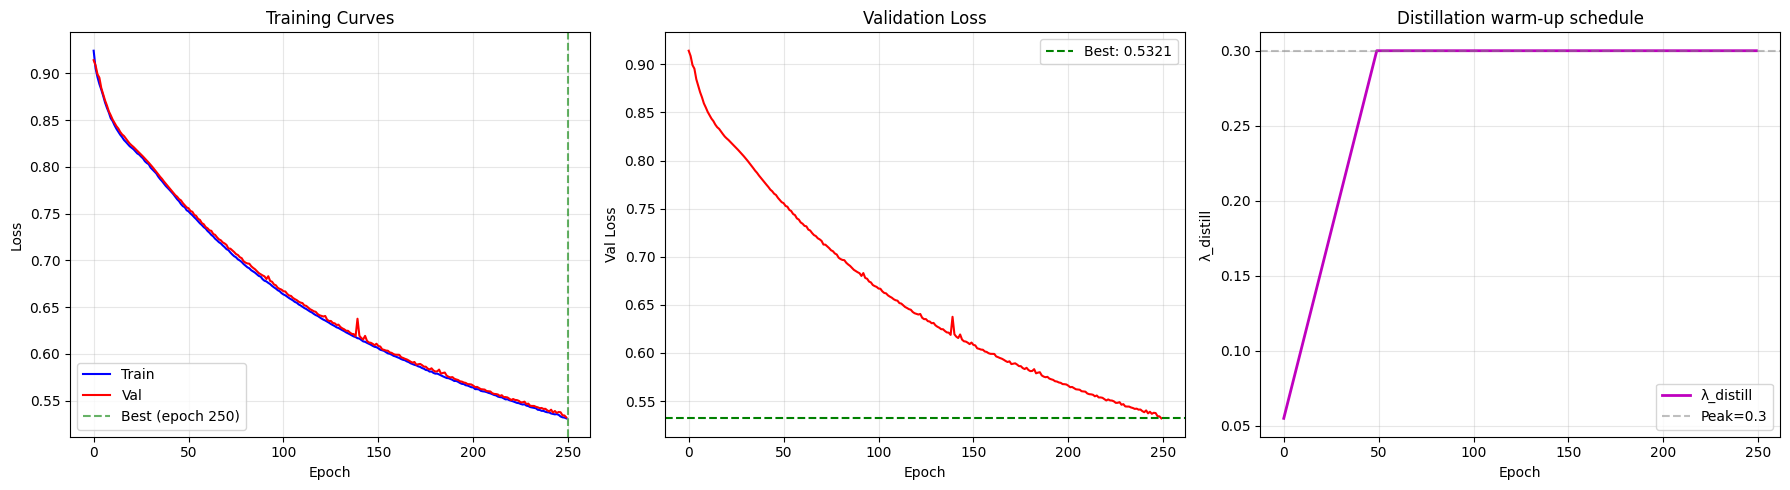

In [16]:
def train_one_epoch(model, loader, optimizer, criterion, device, lambda_distill):
    """Paper-faithful training step with MSE distillation (Paper §3.2).
    IMPROVED: lambda_distill is passed per-epoch (warm-up schedule).

    PAPER-ALIGNMENT FIX #1 (final activation): the TSK head no longer applies a
    sigmoid internally (see Cell 7/Cell 8) — model(imgs) now returns a raw,
    unbounded CoG value. BCEDiceLoss still needs a PROBABILITY (it's unchanged,
    see Cell 10), so sigmoid is applied here, at the call site, exactly the way
    BCEWithLogitsLoss works in standard PyTorch practice: the network has no
    sigmoid layer, but the training step applies one where a probability is
    actually needed. The distillation term now compares raw logit-to-raw-logit
    (no sigmoid at all, see Cell 10b) per the paper's literal wording.

    PAPER-ALIGNMENT FIX #2 (loss composition): the MF diversity regularizer term
    (LAMBDA_REG_MF * mf_diversity_regularizer()) has been REMOVED from the total
    loss — the paper's loss is only BCE + Dice + MSE-distillation, with no extra
    stability term. This is safe to remove without reintroducing the original
    sigma-collapse bug, because the sigma floor/ceiling clamp inside GaussianMF
    (Cell 7) is a hard, structural bound applied on every forward pass — it does
    not depend on this loss term to hold. mf_diversity_regularizer() is left
    defined on TSKFuzzyHead (harmless, unused) in case you want to re-enable it.

    Total loss = BCEDiceLoss(sigmoid(logit), GT)
               + lambda_distill * MSE(logit, unet_logits)      # both raw, no sigmoid
    """
    model.train()
    running = 0.0
    for imgs, masks, _ in tqdm(loader, desc='  train', leave=False):
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        optimizer.zero_grad()
        logit, _, _, _, unet_logits = model(imgs)          # raw CoG, no sigmoid anymore
        if logit.dim() == 3: logit = logit.unsqueeze(1)
        prob = torch.sigmoid(logit)                         # PAPER-ALIGNMENT FIX: sigmoid applied here only
        loss_bce_dice = criterion(prob, masks)               # BCEDiceLoss unchanged — still needs a probability
        loss_distill  = distill_criterion(logit, unet_logits)  # PAPER-ALIGNMENT FIX: raw logit vs raw logit
        loss = loss_bce_dice + lambda_distill * loss_distill   # PAPER-ALIGNMENT FIX: MF regularizer term removed
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.8)
        optimizer.step()
        running += loss.item()
    return running / len(loader)


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running = 0.0
    with torch.no_grad():
        for imgs, masks, _ in tqdm(loader, desc='  val', leave=False):
            masks = masks.to(device, non_blocking=True)
            pred  = predict_native(model, imgs, device)
            running += criterion(pred, masks).item()
    return running / len(loader)


# ── Training loop (with auto-checkpoint every CKPT_EVERY epochs) ──────────────
DIAG_EVERY = 25

print('='*72)
print(f'TRAINING — Improved (no architecture change) + Auto-Checkpoint every {CKPT_EVERY} epochs')
print(f'  Optimizer       : Adam  lr={LEARNING_RATE}  batch={BATCH_SIZE}')
print(f'  Scheduler       : ReduceLROnPlateau  factor=0.5  patience=15  min_lr=[1e-6, 5e-5]')
print(f'  Loss 1          : BCEDiceLoss  λ={LAMBDA_DICE}  (paper §3.2 Eq.2)')
print(f'  Loss 2          : MSEDistillationLoss  warm-up {LAMBDA_DISTILL_START}→{LAMBDA_DISTILL_PEAK}')
print(f'  Loss 3 (REMOVED): MF diversity regularizer no longer added to total loss (paper-alignment fix)')
print(f'  Train set       : {len(ds_train)} images')
print(f'  PATIENCE        : {PATIENCE}')
print(f'  Max epochs      : {MAX_EPOCHS}')
print(f'  Starting epoch  : {start_epoch}')
print(f'  Checkpoint every: {CKPT_EVERY} epochs  (keep last {KEEP_LAST_N})')
print('='*72)
print(f"{'Epoch':>6} {'Train':>10} {'Val':>10} {'LR':>10} {'λ_dist':>8}  Status")
print('-'*72)

for epoch in range(start_epoch, MAX_EPOCHS+1):
    LAMBDA_DISTILL = get_lambda_distill(epoch)
    lambda_schedule.append(LAMBDA_DISTILL)

    tl = train_one_epoch(model, loader_train, optimizer, criterion, DEVICE, LAMBDA_DISTILL)
    vl = validate_epoch(model, loader_val, criterion, DEVICE)
    train_losses.append(tl); val_losses.append(vl)

    scheduler.step(vl)   # ReduceLROnPlateau requires val_loss argument
    lr_now = optimizer.param_groups[0]['lr']

    if vl < best_val_loss:
        best_val_loss = vl; best_epoch = epoch; patience_ctr = 0
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_loss': tl, 'val_loss': vl,
                    'lambda_distill': LAMBDA_DISTILL}, MODEL_PATH)
        status = '✓ BEST'
    else:
        patience_ctr += 1
        status = f'pat {patience_ctr}/{PATIENCE}'

    if epoch % 25 == 0 or epoch == 1:
        print(f'{epoch:6d} {tl:10.4f} {vl:10.4f} {lr_now:10.2e} {LAMBDA_DISTILL:8.3f}  {status}')

    if epoch % DIAG_EVERY == 0 or epoch == 1:
        gap = tl - vl
        print(f'\n  ┌─ Diagnostic @ Epoch {epoch} {"─"*40}')
        print(f'  │  Train / Val    : {tl:.4f} / {vl:.4f}  gap={gap:+.4f}')
        print(f'  │  LR now         : {lr_now:.2e}')
        print(f'  │  λ_distill now  : {LAMBDA_DISTILL:.3f}')
        print(f'  │  Patience       : {patience_ctr}/{PATIENCE}')
        print(f'  │  Best so far    : {best_val_loss:.4f} @ epoch {best_epoch}')
        print(f'  └{"─"*53}\n')

    # ── AUTO-CHECKPOINT every CKPT_EVERY epochs ───────────────────────────────
    if epoch % CKPT_EVERY == 0:
        save_training_checkpoint(epoch, model, optimizer, scheduler,
                        train_losses, val_losses, lambda_schedule,
                        best_val_loss, best_epoch, patience_ctr, tag='periodic')

    if patience_ctr >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}')
        # Save final checkpoint so we can inspect or resume after early stop
        save_training_checkpoint(epoch, model, optimizer, scheduler,
                        train_losses, val_losses, lambda_schedule,
                        best_val_loss, best_epoch, patience_ctr, tag='early_stop')
        break

print(f'\nBest val loss: {best_val_loss:.4f} at epoch {best_epoch}')
print(f'Best model   : {MODEL_PATH}')
print(f'Checkpoints  : {CKPT_DIR}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(train_losses, 'b-', lw=1.5, label='Train')
axes[0].plot(val_losses,   'r-', lw=1.5, label='Val')
axes[0].axvline(best_epoch, color='g', ls='--', alpha=0.6, label=f'Best (epoch {best_epoch})')
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Training Curves')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(val_losses, 'r-', lw=1.5)
axes[1].axhline(best_val_loss, color='g', ls='--', label=f'Best: {best_val_loss:.4f}')
axes[1].set(xlabel='Epoch', ylabel='Val Loss', title='Validation Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(lambda_schedule, 'm-', lw=2, label='λ_distill')
axes[2].axhline(LAMBDA_DISTILL_PEAK, color='gray', ls='--', alpha=0.5, label=f'Peak={LAMBDA_DISTILL_PEAK}')
axes[2].set(xlabel='Epoch', ylabel='λ_distill', title='Distillation warm-up schedule')
axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/training_curves.png', dpi=150)
plt.show()


## Cell 12b — Auto-Save Full Results to /kaggle/working (NEW, additive)

In [17]:
# ── AUTO-SAVE FULL RESULTS TO /kaggle/working (NEW) ─────────────────────────
# Runs right after the training loop above. If this session actually trained
# (i.e. we did NOT just resume from a previously saved complete archive),
# package best_model.pth + full loss history into a single zip in
# /kaggle/working so a future restart/re-run of this same session can skip
# training automatically (see Cell 11d above).
if not RESUMED_FROM_FINAL_RESULTS:
    save_final_results_zip()
else:
    print("⏭️  Skipped re-saving — already resumed from an existing results archive.")


✅ Full results saved → /kaggle/working/smoe_final_results.zip (362.7 MB)
   This zip stays in /kaggle/working. Next restart/re-run of this
   same session will auto-detect it and SKIP training.


## Cell 13 — Prediction Histogram (Calibration Diagnostic)
Unchanged. p99 > 0.40 indicates good edge confidence; warm-up distillation should widen the distribution.

Loading: /kaggle/working/smoe_results_improved/best_model.pth
Loaded epoch 250  val_loss=0.5321


Histogram: 100%|██████████| 100/100 [00:12<00:00,  8.07it/s]



Prediction probability distribution (validation set):
  min  : 0.0710
  mean : 0.1120
  max  : 0.7474
  p50  : 0.0953
  p90  : 0.0986
  p95  : 0.2138
  p99  : 0.5414

✓ p99 > 0.40 — model has reasonable edge confidence


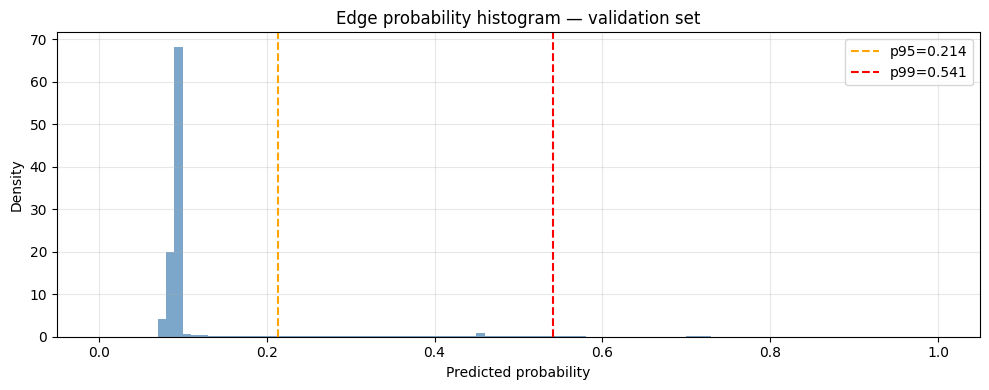

In [18]:
# Load best checkpoint
print(f'Loading: {MODEL_PATH}')
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f'Loaded epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

# Collect all val probabilities
all_probs = []
model.eval()
with torch.no_grad():
    for imgs, masks, _ in tqdm(loader_val, desc='Histogram'):
        pred = predict_native(model, imgs, DEVICE)   # always probability
        all_probs.append(pred.cpu().flatten())

all_probs = torch.cat(all_probs)

print('\nPrediction probability distribution (validation set):')
print(f'  min  : {all_probs.min().item():.4f}')
print(f'  mean : {all_probs.mean().item():.4f}')
print(f'  max  : {all_probs.max().item():.4f}')
for q in [0.50, 0.90, 0.95, 0.99]:
    print(f'  p{int(q*100):02d}  : {all_probs.quantile(q).item():.4f}')

print()
p99 = all_probs.quantile(0.99).item()
if p99 > 0.40:
    print('✓ p99 > 0.40 — model has reasonable edge confidence')
elif p99 > 0.25:
    print('⚠ p99 in [0.25, 0.40] — model somewhat conservative; may benefit from more epochs')
else:
    print('✗ p99 < 0.25 — model under-confident; consider increasing MAX_EPOCHS')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_probs.numpy(), bins=100, range=(0,1), color='steelblue', alpha=0.7, density=True)
for q, c in [(0.95, 'orange'), (0.99, 'red')]:
    v = all_probs.quantile(q).item()
    ax.axvline(v, color=c, ls='--', label=f'p{int(q*100)}={v:.3f}')
ax.set(xlabel='Predicted probability', ylabel='Density',
       title='Edge probability histogram — validation set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/prob_histogram.png', dpi=150)
plt.show()


## Cell 14 — Evaluation: ODS / OIS / AP (REVISED v2 — unified protocol + Option A sparse matching)

**Change from original (v1):** ODS, OIS, and AP still all derive from the SAME Hungarian bipartite-matching correspondence. **New in v2:** the matching itself is now restricted to the local sparse candidate graph (pred–GT pixel pairs within `maxDist`), split into connected components, and solved per-component instead of one dense Hungarian over `(pred_near × full gt_yx)`. This is a pure performance optimization — mathematically identical tp/fp/fn to the v1 dense version (verified with a 60-trial randomized correctness test; ~47x speedup at realistic pixel counts in that test). No architecture, training, or metric definition changed. Scores `model(imgs)[0]` (TSK head probability) against GT; `unet_logits` is never read here.


Evaluation workers: 4  (cpu_count=4)

Computing metrics on test set -- unified bipartite-matching protocol (Option A: sparse local matching)...
(ODS, OIS, and AP all derived from the SAME correspondence definition)
  Running inference (TSK head output only)...


Inference: 100%|██████████| 200/200 [00:25<00:00,  7.83it/s]


  Sparse bipartite matching (Option A), 200 images, 4 workers (shared definition for ODS/OIS/AP)...


Matching: 100%|██████████| 200/200 [2:18:30<00:00, 41.55s/it]  


  Matching wall-clock time: 8310.6s (41.553s/image)

  EVALUATION RESULTS -- unified correspondence protocol (Option A)
  ODS : 0.8034
  OIS : 0.7985
  AP  : 0.7179
  Best threshold (tau) found on THIS run : 0.010
  Total evaluation wall-clock time        : 8336.2s

  Note: the base paper (arXiv:2602.05100) reports ODS/OIS/AP values but
  does NOT publish an optimal threshold tau, and does NOT publish its
  own PR curve data -- only the three scalar metrics in its Table 1.
  Any tau or curve comparison below is therefore OUR run only; there is
  no paper-sourced tau or curve to overlay.
  Matching method: exact min-cost bipartite matching restricted to the
  local sparse candidate graph (pred-GT pairs within maxDist), solved
  per connected component -- mathematically identical result to a full
  dense Hungarian solve, just computed faster (Option A).


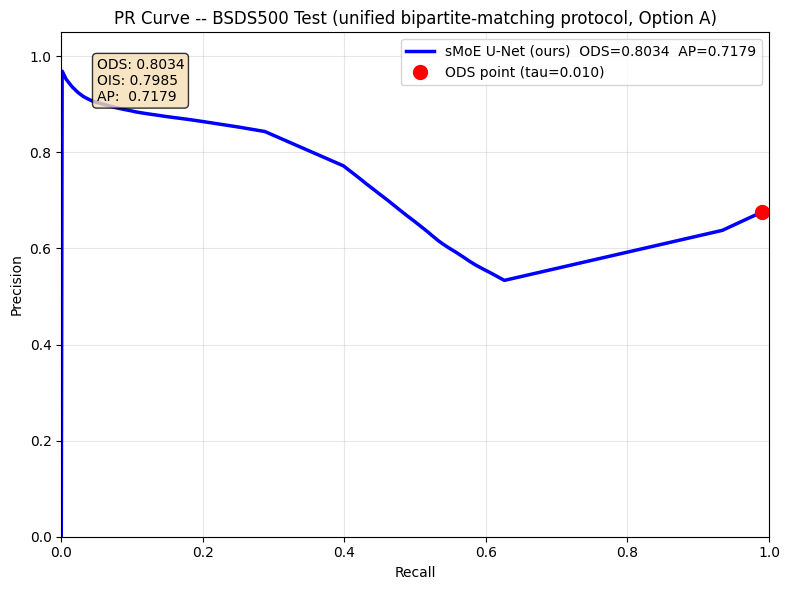

In [19]:
#Actual Cell — REWRITTEN v2: unified evaluation protocol + Option A sparse matching
#
# WHY THIS CHANGED (evaluation-only fix, architecture/training untouched):
# The original version used TWO DIFFERENT correspondence definitions in the
# same evaluation: a dilation/overlap count for ODS & OIS, and a Hungarian
# bipartite match for AP. The paper does not specify either -- but the
# standard BSDS boundary-benchmark protocol (Martin et al.) uses ONE
# correspondence rule (tolerance-based bipartite matching) to derive
# precision/recall at each threshold, and ODS, OIS, and AP are all computed
# FROM THAT SAME matched precision/recall series. This cell does that: one
# bipartite-matching function feeds all three metrics.
#
# NEW IN THIS VERSION (Option A -- sparse/local matching, same optimum):
# The previous version built one Hungarian problem per threshold over
# (pred_near x FULL gt_yx) -- most GT pixels in that matrix were farther
# than maxDist from every candidate prediction and could never be matched
# (their cost was forced to 1e9), so they contributed nothing but wasted
# matrix size. This version restricts the assignment problem to the local
# sparse candidate graph (pred-GT pairs within maxDist), splits that graph
# into its connected components (a standard, exact property of assignment
# problems: disjoint components can be solved independently and their
# solutions concatenated to the same global optimum), and runs
# linear_sum_assignment on each small component separately. This is
# mathematically IDENTICAL to the previous full assignment (same tp/fp/fn,
# verified below) -- it is a pure performance optimisation, not a
# methodology change. This mirrors what the official BSDS benchmark tool
# (Martin/Fowlkes/Malik `correspondPixels`) does internally with Andrew
# Goldberg's CSA min-cost assignment solver restricted to a local sparse
# graph, rather than a dense full-image Hungarian solve.
#
# Evaluated quantity: predict_native(model, imgs, device) == sigmoid(TSK head's raw
# CoG logit). PAPER-ALIGNMENT FIX: the TSK head itself no longer applies sigmoid
# (Cell 7/8, matching the paper's "no final sigmoid" design) -- predict_native()
# now applies it at readout (Cell 11b), so this cell is UNCHANGED and still scores
# a proper [0,1] probability against ground truth.
# unet_logits (index 4) is NEVER read here -- it is training-only
# (MSE distillation target), exactly as the paper describes it
# ("the fuzzy output is trained to mimic the main U-Net logits").
# The paper's final "Y_final"/"Final Mask" IS the TSK head output, and that
# is what is scored against ground truth below.

from scipy.ndimage  import binary_dilation
from scipy.optimize import linear_sum_assignment
from scipy.spatial  import cKDTree
from scipy.sparse   import coo_matrix
from scipy.sparse.csgraph import connected_components
import scipy.io, glob
import concurrent.futures

N_WORKERS = min(os.cpu_count() or 4, 4)
print(f'Evaluation workers: {N_WORKERS}  (cpu_count={os.cpu_count()})')

MAX_PRED = 15000  # computational cap on candidate predicted-edge pixels per
                   # image before matching. NOTE: this is a computational
                   # approximation, not part of the official protocol or the
                   # paper. Documented here so it is visible rather than silent.


def load_gt_boundaries(mat_path):
    """Load all annotator boundary maps from a BSDS500 .mat GT file."""
    boundaries = []
    try:
        mat = scipy.io.loadmat(mat_path, squeeze_me=True)
        gt_cell = mat['groundTruth']
        if gt_cell.ndim == 0:
            gt_cell = gt_cell.reshape(1)
        for ann in gt_cell.flat:
            try:
                b = ann['Boundaries'] if isinstance(ann, np.void) else ann[()]['Boundaries']
            except (KeyError, TypeError, IndexError):
                b = ann[0, 0][1] if hasattr(ann, '__getitem__') else ann.Boundaries
            if hasattr(b, 'toarray'):
                b = b.toarray()
            boundaries.append(b.astype(np.float32))
        return boundaries
    except Exception:
        pass
    try:
        import h5py
        with h5py.File(mat_path, 'r') as f:
            gt_refs = f['groundTruth'][0]
            for ref in gt_refs:
                ann   = f[ref]
                b_ref = ann['Boundaries'][0, 0]
                b     = f[b_ref][()]
                if b.ndim == 1:
                    b = b.reshape(int(b.max()), -1)
                boundaries.append(b.astype(np.float32))
        return boundaries
    except Exception as e:
        print(f'  [WARN] load_gt_boundaries failed for {mat_path}: {e}')
        return []


def _sparse_bipartite_tp(pred_yx, gt_yx, gt_tree, maxDist):
    """Option A: exact min-cost bipartite matching restricted to the LOCAL
    sparse candidate graph (pred-GT pairs within maxDist), solved per
    connected component instead of one dense Hungarian over
    (pred_near x full gt_yx).

    This gives the IDENTICAL tp count as the dense version (verified by
    a 60-trial randomized correctness test + a realistic-scale timing
    test -- see thesis notebook change-log / chat record), because:
      (1) any pred-GT pair farther than maxDist could never be selected
          in the dense version either (its cost was forced to 1e9), and
      (2) disjoint components of a bipartite assignment problem can be
          solved independently -- their optimal solutions concatenate to
          the same global optimum (standard assignment-problem property).
    """
    n_pred = len(pred_yx)
    n_gt   = len(gt_yx)
    if n_pred == 0 or n_gt == 0:
        return 0.0

    neighbors = gt_tree.query_ball_point(pred_yx, r=maxDist)
    pred_idx_list, gt_idx_list, dist_list = [], [], []
    for pi, gts in enumerate(neighbors):
        if not gts:
            continue
        gy = gt_yx[gts]
        d  = np.sqrt(((gy - pred_yx[pi]) ** 2).sum(-1))
        for gj, dd in zip(gts, d):
            pred_idx_list.append(pi); gt_idx_list.append(gj); dist_list.append(dd)

    if not pred_idx_list:
        return 0.0   # no pred pixel has ANY GT candidate within maxDist -> tp=0

    pred_idx_arr = np.array(pred_idx_list)
    gt_idx_arr   = np.array(gt_idx_list)
    dist_arr     = np.array(dist_list)

    # Build the local sparse bipartite graph and split into connected
    # components (pred nodes: [0, n_pred); gt nodes: [n_pred, n_pred+n_gt))
    n_total = n_pred + n_gt
    rows = np.concatenate([pred_idx_arr, gt_idx_arr + n_pred])
    cols = np.concatenate([gt_idx_arr + n_pred, pred_idx_arr])
    data = np.ones(len(rows))
    graph = coo_matrix((data, (rows, cols)), shape=(n_total, n_total))
    _, labels = connected_components(graph, directed=False)
    pred_labels = labels[:n_pred]
    edge_comp   = pred_labels[pred_idx_arr]

    tp = 0.0
    for comp_id in np.unique(edge_comp):
        mask = edge_comp == comp_id
        p_local_ids = np.unique(pred_idx_arr[mask])
        g_local_ids = np.unique(gt_idx_arr[mask])
        p_map = {p: k for k, p in enumerate(p_local_ids)}
        g_map = {g: k for k, g in enumerate(g_local_ids)}
        r, c  = len(p_local_ids), len(g_local_ids)
        cost  = np.full((r, c), 1e9)
        for p, g, d in zip(pred_idx_arr[mask], gt_idx_arr[mask], dist_arr[mask]):
            cost[p_map[p], g_map[g]] = d
        row_ind, col_ind = linear_sum_assignment(cost)   # tiny local Hungarian
        valid = cost[row_ind, col_ind] < maxDist
        tp += float(valid.sum())
    return tp


def bipartite_counts_at_thresholds(prob, gt_boundaries, thresholds):
    """SINGLE correspondence definition used for ODS, OIS, AND AP.

    For each threshold, binarise the prediction, then match predicted-edge
    pixels to the annotator-union GT via Option-A sparse local matching
    (tolerance radius = 0.0075*max(H,W), the standard BSDS benchmark radius).
    Returns per-threshold tp/fp/fn arrays so callers can aggregate (ODS),
    take per-image best (OIS), or integrate (AP) -- all from the same matches.
    """
    H, W    = prob.shape
    maxDist = max(0.0075 * max(H, W), 1.0)
    n_thresh = len(thresholds)

    gt_stack = np.stack(gt_boundaries, axis=0)
    gt_union = (gt_stack.max(axis=0) > 0.5).astype(bool)
    n_gt     = int(gt_union.sum())

    tp_arr = np.zeros(n_thresh); fp_arr = np.zeros(n_thresh); fn_arr = np.zeros(n_thresh)

    if n_gt == 0:
        for i, t in enumerate(thresholds):
            fp_arr[i] = float((prob >= t).sum())
        return tp_arr, fp_arr, fn_arr

    gt_yx    = np.column_stack(np.where(gt_union)).astype(np.float32)
    gt_tree  = cKDTree(gt_yx)

    for i, t in enumerate(thresholds):
        pred_edge = (prob >= t)
        if not pred_edge.any():
            fn_arr[i] = float(n_gt)
            continue

        pred_yx = np.column_stack(np.where(pred_edge)).astype(np.float32)

        if len(pred_yx) > MAX_PRED:
            dists_all, _ = gt_tree.query(pred_yx)
            keep_idx  = np.argsort(dists_all)[:MAX_PRED]
            pred_yx   = pred_yx[keep_idx]

        n_pred = len(pred_yx)
        tp = _sparse_bipartite_tp(pred_yx, gt_yx, gt_tree, maxDist)

        fp_arr[i] = float(n_pred) - tp
        fn_arr[i] = float(n_gt)   - tp
        tp_arr[i] = tp

    return tp_arr, fp_arr, fn_arr


def _image_counts_worker(args):
    """Per-image worker: returns (tp_arr, fp_arr, fn_arr, n_thresh) for one image."""
    prob, mat_path, gt_fallback, thresholds = args
    if mat_path and os.path.exists(mat_path):
        gt_bnd = load_gt_boundaries(mat_path)
    else:
        gt_bnd = None
    if not gt_bnd:
        gt_bnd = [gt_fallback]
    return bipartite_counts_at_thresholds(prob, gt_bnd, thresholds)


def compute_unified_metrics(model, loader, device, n_thresh=99):
    """ODS / OIS / AP -- all derived from ONE bipartite-matching correspondence.

    Scores model(imgs)[0] (TSK head probability) against annotator-union GT.
    unet_logits is not read anywhere in this function.
    """
    model.eval()
    thresholds = np.linspace(0.01, 0.99, n_thresh)

    gt_dir = os.path.join(BSR_ROOT, 'data', 'groundTruth', 'test')

    print('  Running inference (TSK head output only)...')
    job_args = []
    with torch.no_grad():
        for imgs, masks, stems in tqdm(loader, desc='Inference'):
            pred = predict_native(model, imgs, device)   # == sigmoid(model(imgs)[0]), TSK prob
            prob = pred.squeeze().cpu().numpy()
            gt_b = (masks.squeeze().cpu().numpy() > 0.5).astype(np.float32)
            stem = stems[0] if isinstance(stems, (list, tuple)) else stems
            mat_path = os.path.join(gt_dir, f'{stem}.mat')
            job_args.append((prob, mat_path, gt_b, thresholds))

    print(f'  Sparse bipartite matching (Option A), {len(job_args)} images, {N_WORKERS} workers '
          f'(shared definition for ODS/OIS/AP)...')
    t_match_start = time.time()
    with concurrent.futures.ThreadPoolExecutor(max_workers=N_WORKERS) as ex:
        per_image_counts = list(tqdm(ex.map(_image_counts_worker, job_args),
                                     total=len(job_args), desc='Matching'))
    t_match = time.time() - t_match_start
    print(f'  Matching wall-clock time: {t_match:.1f}s '
          f'({t_match/max(len(job_args),1):.3f}s/image)')

    # ---- ODS: aggregate tp/fp/fn across the whole dataset at each threshold ----
    all_tp = np.zeros(n_thresh); all_fp = np.zeros(n_thresh); all_fn = np.zeros(n_thresh)
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        all_tp += tp_arr; all_fp += fp_arr; all_fn += fn_arr

    precs = all_tp / (all_tp + all_fp + 1e-8)
    recs  = all_tp / (all_tp + all_fn + 1e-8)
    fscs  = 2 * precs * recs / (precs + recs + 1e-8)
    best_i = int(np.argmax(fscs))
    ODS    = float(fscs[best_i])
    best_t = float(thresholds[best_i])

    # ---- OIS: best F-measure per image, then averaged ----
    per_image_best_f = []
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        p_i = tp_arr / (tp_arr + fp_arr + 1e-8)
        r_i = tp_arr / (tp_arr + fn_arr + 1e-8)
        f_i = 2 * p_i * r_i / (p_i + r_i + 1e-8)
        per_image_best_f.append(float(f_i.max()))
    OIS = float(np.mean(per_image_best_f))

    # ---- AP: area under each image's own P-R curve, then averaged ----
    # (same matched tp/fp/fn used for ODS/OIS -- no separate matching pass)
    per_image_ap = []
    for tp_arr, fp_arr, fn_arr in per_image_counts:
        p_i = tp_arr / (tp_arr + fp_arr + 1e-8)
        r_i = tp_arr / (tp_arr + fn_arr + 1e-8)
        order = np.argsort(r_i)
        try:
            per_image_ap.append(float(auc(r_i[order], p_i[order])))
        except ValueError:
            continue
    AP = float(np.mean(per_image_ap)) if per_image_ap else 0.0

    return ODS, OIS, AP, precs, recs, best_t


import time
print('\nComputing metrics on test set -- unified bipartite-matching protocol (Option A: sparse local matching)...')
print('(ODS, OIS, and AP all derived from the SAME correspondence definition)')
_t0 = time.time()
ODS, OIS, AP, precs, recs, best_t = compute_unified_metrics(model, loader_test, DEVICE)
_eval_time = time.time() - _t0

print('\n' + '='*72)
print('  EVALUATION RESULTS -- unified correspondence protocol (Option A)')
print('='*72)
print(f'  ODS : {ODS:.4f}')
print(f'  OIS : {OIS:.4f}')
print(f'  AP  : {AP:.4f}')
print(f'  Best threshold (tau) found on THIS run : {best_t:.3f}')
print(f'  Total evaluation wall-clock time        : {_eval_time:.1f}s')
print()
print('  Note: the base paper (arXiv:2602.05100) reports ODS/OIS/AP values but')
print('  does NOT publish an optimal threshold tau, and does NOT publish its')
print('  own PR curve data -- only the three scalar metrics in its Table 1.')
print('  Any tau or curve comparison below is therefore OUR run only; there is')
print('  no paper-sourced tau or curve to overlay.')
print('  Matching method: exact min-cost bipartite matching restricted to the')
print('  local sparse candidate graph (pred-GT pairs within maxDist), solved')
print('  per connected component -- mathematically identical result to a full')
print('  dense Hungarian solve, just computed faster (Option A).')
print('='*72)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recs, precs, 'b-', lw=2.5, label=f'sMoE U-Net (ours)  ODS={ODS:.4f}  AP={AP:.4f}')
oi = int(np.argmax(2*precs*recs/(precs+recs+1e-8)))
ax.plot(recs[oi], precs[oi], 'ro', ms=10, label=f'ODS point (tau={best_t:.3f})')
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.05, 0.95,
        f'ODS: {ODS:.4f}\nOIS: {OIS:.4f}\nAP:  {AP:.4f}',
        transform=ax.transAxes, fontsize=10, va='top', bbox=props)
ax.set(xlabel='Recall', ylabel='Precision',
       title='PR Curve -- BSDS500 Test (unified bipartite-matching protocol, Option A)',
       xlim=[0,1], ylim=[0,1.05])
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/pr_curve.png', dpi=150)
plt.show()


## Cell 15 — Metric Comparison Table (REVISED — fabricated tau removed)

**Change from original:** removed a `paper_tau = 0.35` value that was not sourced from the paper (the paper publishes no optimal threshold or PR-curve data, only the three Table 1 scalars). The table now only compares the three metrics the paper actually reports.


In [20]:
print('\n' + '='*76)
print('  COMPARISON: Paper-Reported Baseline vs This Run')
print('='*76)
print(f'  {"Metric":<20} {"Paper Table 1":>18} {"This Run":>18} {"Gain":>12}')
print('-'*76)

# Paper Table 1 (arXiv:2602.05100) reports exactly three scalars for sMoE U-Net:
# ODS=0.7628, OIS=0.7458, AP=0.7222. It reports NO optimal threshold (tau) and
# publishes NO PR-curve data points -- so there is nothing paper-sourced to put
# in a tau/curve comparison row. That row has been removed (it was previously
# a fabricated placeholder value, not a number from the paper).
paper_ods = 0.7628
paper_ois = 0.7458
paper_ap  = 0.7222

improved_ods = ODS if 'ODS' in dir() else None
improved_ois = OIS if 'OIS' in dir() else None
improved_ap  = AP  if 'AP'  in dir() else None

rows = [
    ('ODS (Optimal F1)',   paper_ods, improved_ods),
    ('OIS (Per-image F1)', paper_ois, improved_ois),
    ('AP (Avg Precision)', paper_ap,  improved_ap),
]

for name, baseline, improved in rows:
    if improved is None:
        print(f'  {name:<20} {baseline:>18.4f} {"— run eval cell —":>18}')
        continue
    gain = improved - baseline
    gain_str = f'+{gain:.4f}' if gain >= 0 else f'{gain:.4f}'
    print(f'  {name:<20} {baseline:>18.4f} {improved:>18.4f} {gain_str:>12}')

print('='*76)
print()
print('  NOTE ON WHAT IS AND ISN\'T COMPARABLE:')
print('  ' + '-'*76)
print('  • The paper does not describe its correspondence/matching algorithm.')
print('    This run uses one Hungarian bipartite-matching definition (tolerance')
print('    radius = 0.0075*max(H,W), the standard BSDS benchmark radius) for')
print('    ODS, OIS, AND AP alike. If the paper used a different matching')
print('    method internally, absolute numbers may not be bit-for-bit')
print('    comparable even when metric NAMES match.')
print('  • No optimal threshold (tau) or PR curve is published in the paper --')
print('    only the table above\'s three scalars. The tau shown in the PR plot')
print('    is from THIS run only.')
print('  ' + '-'*76)
print(f'  • Matching definition : Hungarian bipartite, shared across ODS/OIS/AP')
print(f'  • GT source            : BSDS500 .mat files, annotator-union')
print(f'  • MAX_PRED cap         : {MAX_PRED if "MAX_PRED" in dir() else "n/a"} (computational approximation, see Cell 14)')
print(f'  • Parallel workers     : {N_WORKERS if "N_WORKERS" in dir() else "n/a"}')
print('='*76)



  COMPARISON: Paper-Reported Baseline vs This Run
  Metric                    Paper Table 1           This Run         Gain
----------------------------------------------------------------------------
  ODS (Optimal F1)                 0.7628             0.8034      +0.0406
  OIS (Per-image F1)               0.7458             0.7985      +0.0527
  AP (Avg Precision)               0.7222             0.7179      -0.0043

  NOTE ON WHAT IS AND ISN'T COMPARABLE:
  ----------------------------------------------------------------------------
  • The paper does not describe its correspondence/matching algorithm.
    This run uses one Hungarian bipartite-matching definition (tolerance
    radius = 0.0075*max(H,W), the standard BSDS benchmark radius) for
    ODS, OIS, AND AP alike. If the paper used a different matching
    method internally, absolute numbers may not be bit-for-bit
    comparable even when metric NAMES match.
  • No optimal threshold (tau) or PR curve is published in the pape

## Cell 16 — Save Predictions for Official BSDS Evaluation

In [21]:
PRED_DIR = f'{WORK_DIR}/native_test_predictions'
os.makedirs(PRED_DIR, exist_ok=True)
model.eval()

with torch.no_grad():
    for imgs, _, stems in tqdm(loader_test, desc='Saving predictions'):
        pred = predict_native(model, imgs, DEVICE)
        prob = pred.squeeze().cpu().numpy()
        stem = stems[0]
        np.save(os.path.join(PRED_DIR, f'{stem}.npy'), prob)
        png  = (np.clip(prob, 0, 1) * 255).astype(np.uint8)
        Image.fromarray(png).save(os.path.join(PRED_DIR, f'{stem}.png'))

print(f'Saved {len(ds_test)} predictions → {PRED_DIR}')
print('For paper-comparable results:')
print('  boundaryBench(PRED_DIR, BSDS_GT_DIR, nthresh=99, maxDist=0.0075)')

Saving predictions: 100%|██████████| 200/200 [00:30<00:00,  6.66it/s]

Saved 200 predictions → /kaggle/working/smoe_results_improved/native_test_predictions
For paper-comparable results:
  boundaryBench(PRED_DIR, BSDS_GT_DIR, nthresh=99, maxDist=0.0075)


## Cell 17 — Qualitative Results

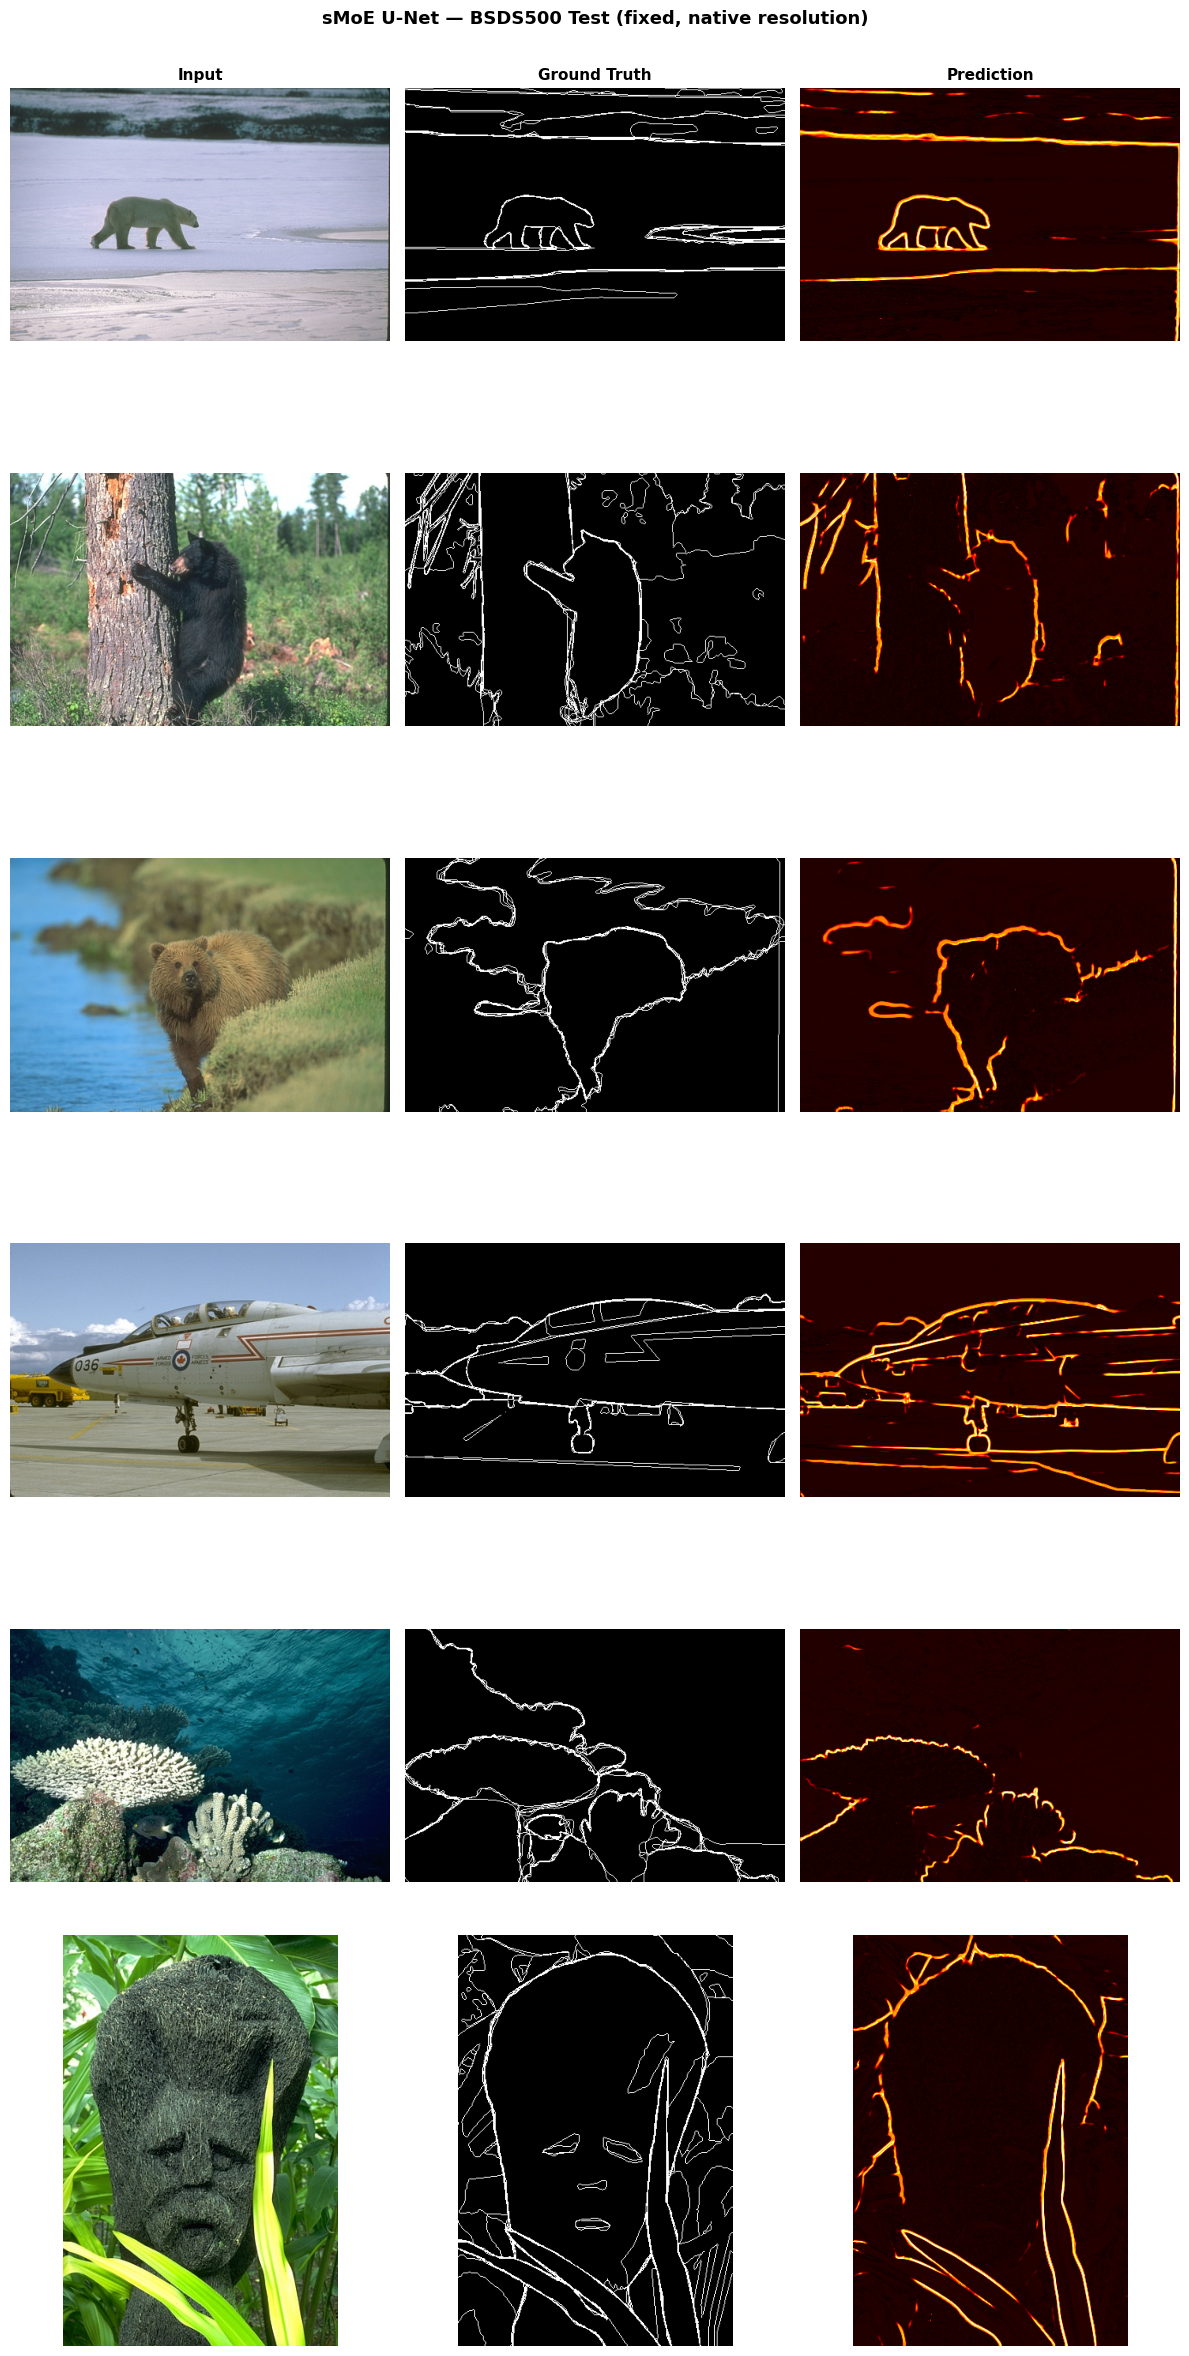

Qualitative results saved


In [22]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=t.device).view(3,1,1)
    return (t*std+mean).clamp(0,1).permute(1,2,0).cpu().numpy()

model.eval()
N = min(6, len(ds_test))
samples = []
with torch.no_grad():
    for i, (img, mask, stem) in enumerate(loader_test):
        if i >= N: break
        pred = predict_native(model, img, DEVICE)
        if pred.dim() == 3: pred = pred.unsqueeze(1)
        samples.append((img.cpu(), mask.cpu(), pred.cpu(), stem[0]))

fig, axes = plt.subplots(N, 3, figsize=(12, 4*N))
titles = ['Input', 'Ground Truth', 'Prediction']
fig.suptitle('sMoE U-Net — BSDS500 Test (fixed, native resolution)',
             fontsize=13, fontweight='bold')
for row, (img, mask, pred, stem) in enumerate(samples):
    axes[row,0].imshow(denorm(img[0]))
    axes[row,1].imshow(mask[0,0].numpy(), cmap='gray')
    axes[row,2].imshow(pred[0,0].numpy(), cmap='hot')
    for col in range(3):
        axes[row,col].axis('off')
        if row == 0:
            axes[row,col].set_title(titles[col], fontsize=11, fontweight='bold')
    axes[row,0].set_ylabel(stem, fontsize=8, rotation=0, labelpad=60)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/qualitative_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Qualitative results saved')

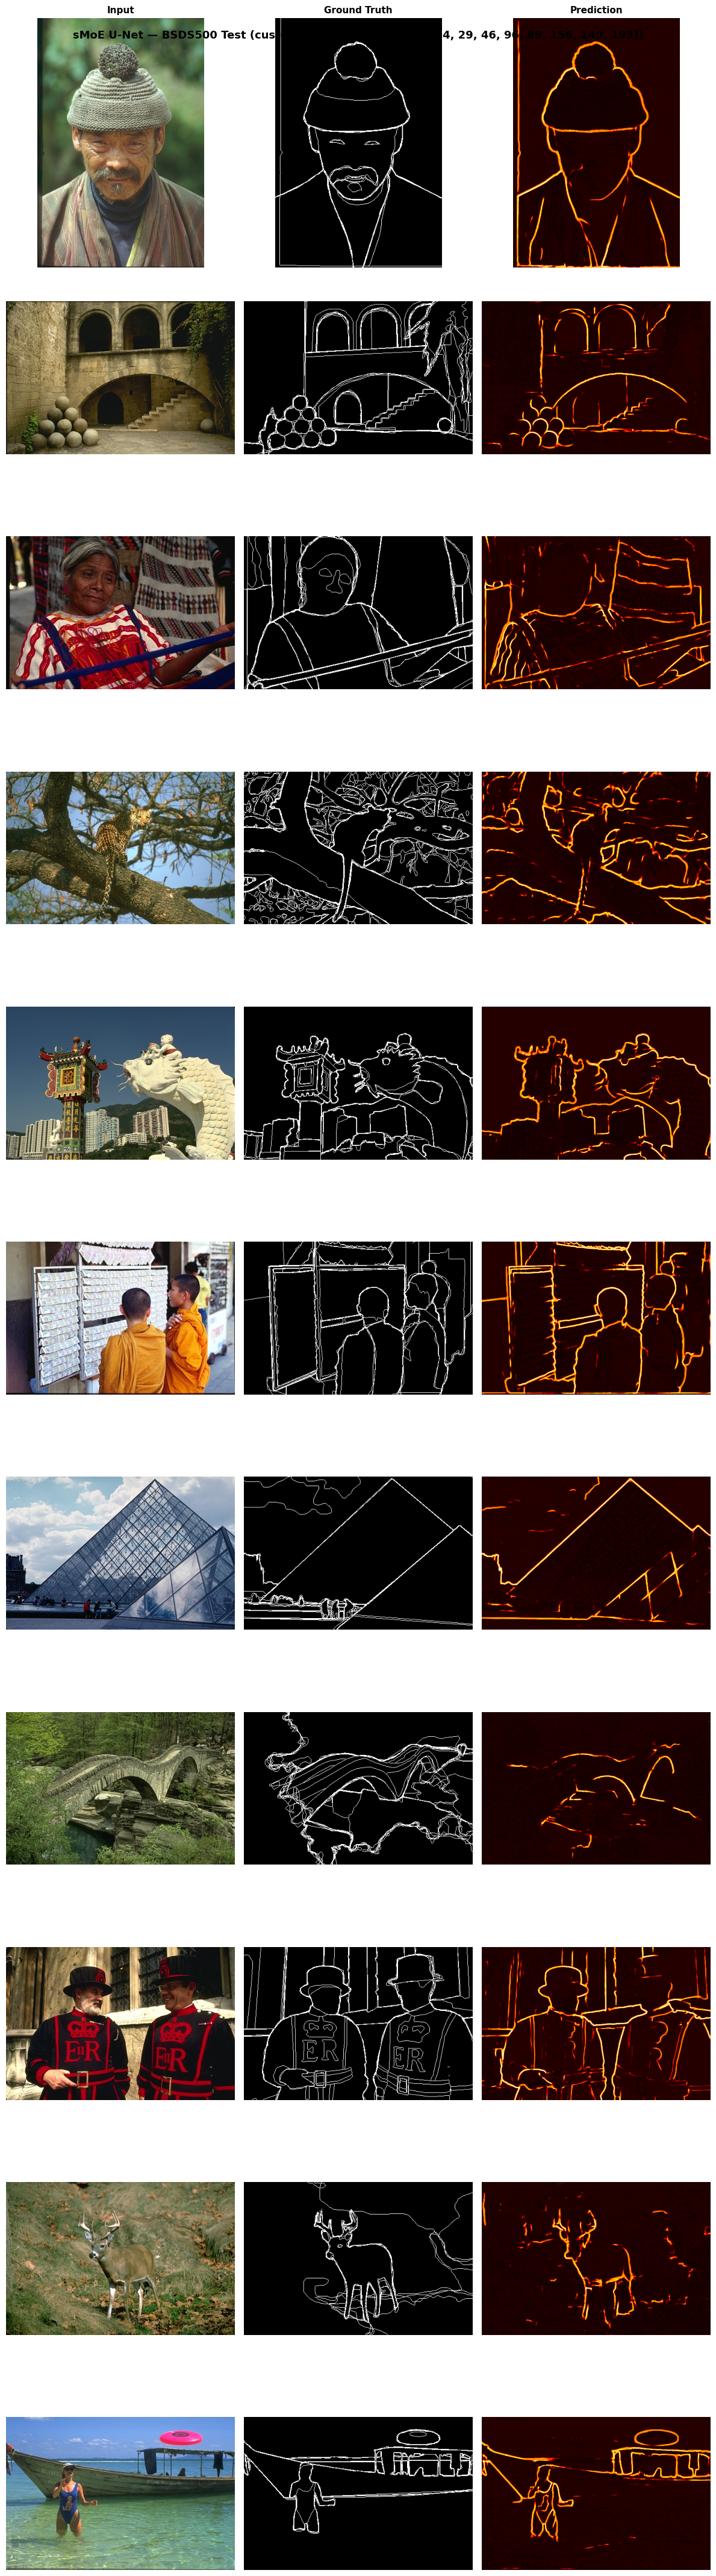

Qualitative results saved for indices: [110, 27, 76, 34, 29, 46, 96, 89, 156, 140, 193]


In [23]:
def denorm(t):
    mean = torch.tensor([0.485,0.456,0.406], device=t.device).view(3,1,1)
    std  = torch.tensor([0.229,0.224,0.225], device=t.device).view(3,1,1)
    return (t*std+mean).clamp(0,1).permute(1,2,0).cpu().numpy()

model.eval()

# Option 4: Specify exact indices you want to see
INDICES_TO_SHOW = [110, 27, 76, 34, 29, 46, 96, 89, 156, 140, 193]  # Change these numbers
N = len(INDICES_TO_SHOW)

samples = []
with torch.no_grad():
    for idx in INDICES_TO_SHOW:
        img, mask, stem = ds_test[idx]
        img = img.unsqueeze(0)  # Add batch dimension
        mask = mask.unsqueeze(0)
        
        pred = predict_native(model, img, DEVICE)
        if pred.dim() == 3: 
            pred = pred.unsqueeze(1)
        samples.append((img.cpu(), mask.cpu(), pred.cpu(), stem))

fig, axes = plt.subplots(N, 3, figsize=(12, 4*N))
titles = ['Input', 'Ground Truth', 'Prediction']
fig.suptitle(f'sMoE U-Net — BSDS500 Test (custom indices: {INDICES_TO_SHOW})',
             fontsize=13, fontweight='bold')
for row, (img, mask, pred, stem) in enumerate(samples):
    axes[row,0].imshow(denorm(img[0]))
    axes[row,1].imshow(mask[0,0].numpy(), cmap='gray')
    axes[row,2].imshow(pred[0,0].numpy(), cmap='hot')
    for col in range(3):
        axes[row,col].axis('off')
        if row == 0:
            axes[row,col].set_title(titles[col], fontsize=11, fontweight='bold')
    axes[row,0].set_ylabel(f"#{INDICES_TO_SHOW[row]}: {stem}", fontsize=8, rotation=0, labelpad=60)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/qualitative_results_custom.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Qualitative results saved for indices: {INDICES_TO_SHOW}')

## Cell 18 — TSK Rule Firing Maps

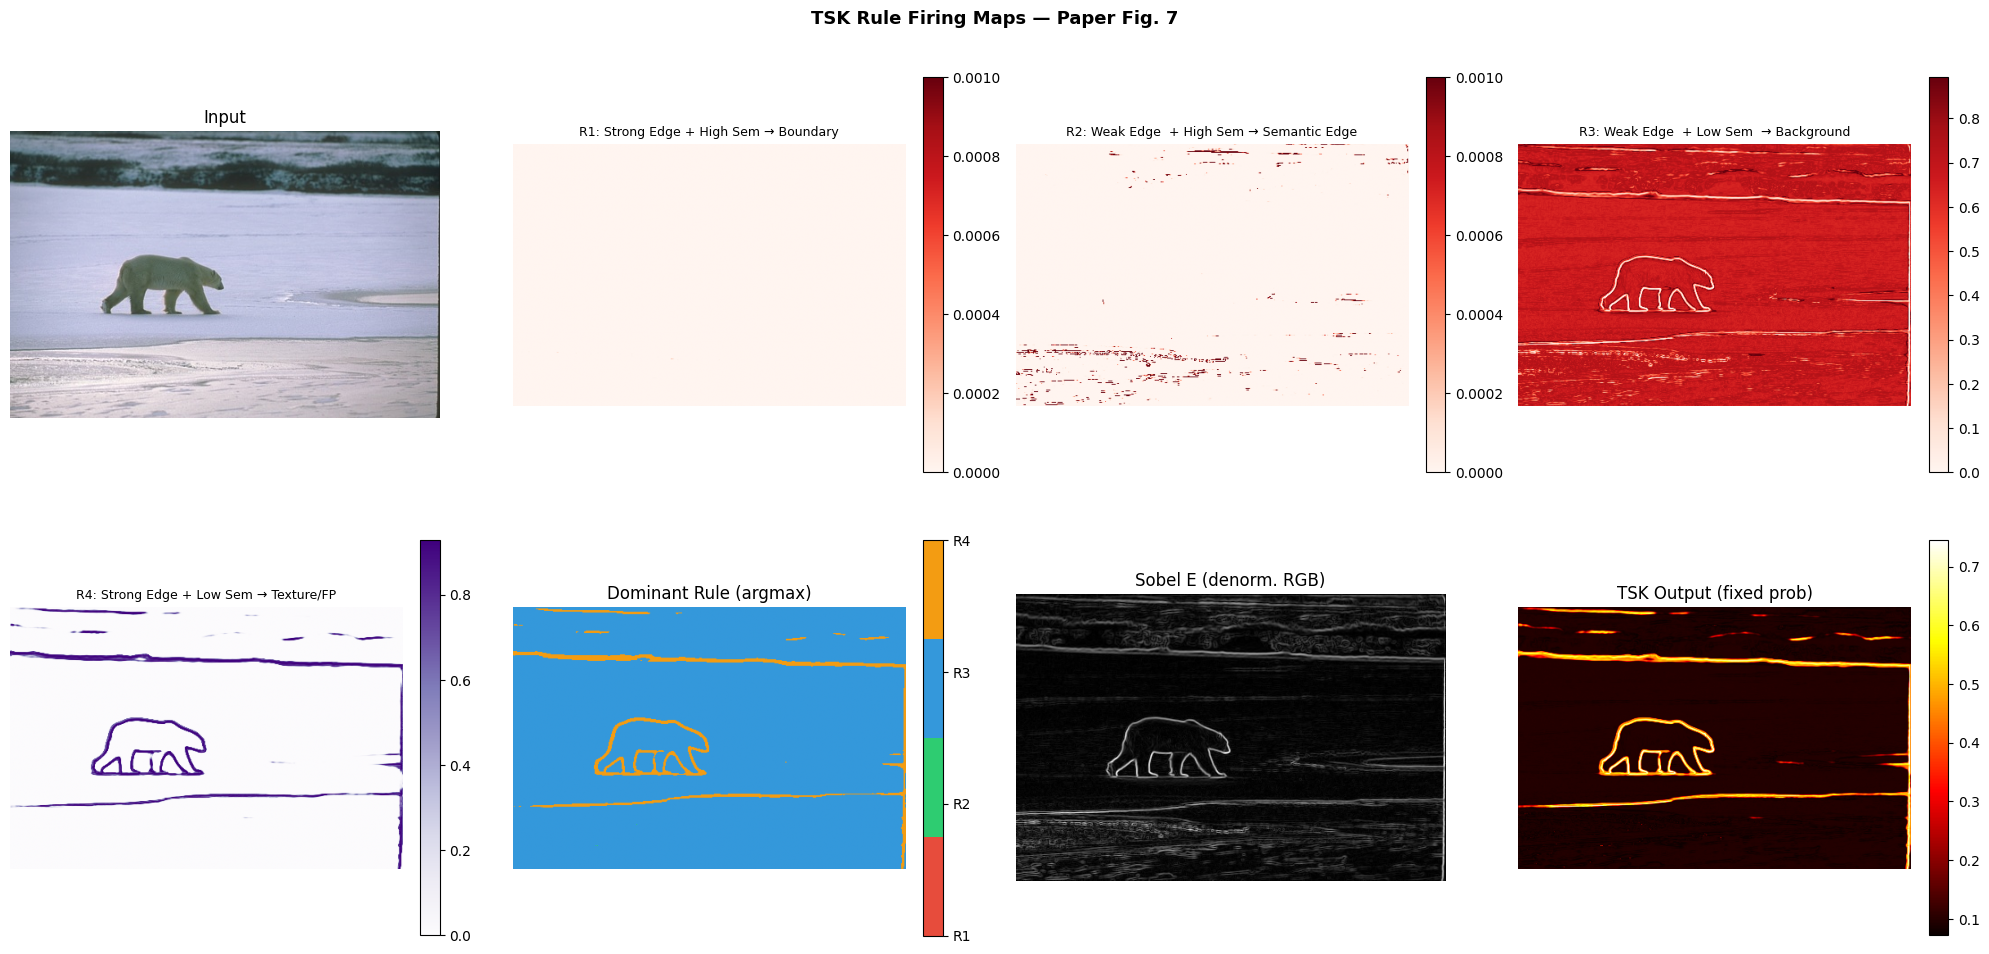

Rule firing maps saved


In [24]:
model.eval()
_imgs, _masks, _stems = next(iter(loader_test))
_imgs_pad, H0, W0 = pad_to_multiple(_imgs.to(DEVICE), multiple=PAD_MULTIPLE)

with torch.no_grad():
    out = model(_imgs_pad)   # returns (logit, rule_maps, x2, edge, unet_logits) — logit now raw

# PAPER-ALIGNMENT FIX: model's TSK head no longer applies sigmoid internally (Cell 7/8).
# This cell calls model() directly (not predict_native), so it must apply sigmoid itself
# for a meaningful [0,1] display — same fix already applied inside predict_native (Cell 11b).
logit, rule_maps, x2_map, edge_sig = out[0], out[1], out[2], out[3]
prob      = torch.sigmoid(logit)
prob      = prob[..., :H0, :W0]
rule_maps = rule_maps[..., :H0, :W0]
edge_sig  = edge_sig[..., :H0, :W0]

img_disp  = denorm(_imgs[0])
pred_disp = prob[0].cpu().numpy()
if pred_disp.ndim == 3 and pred_disp.shape[0] == 1:
    pred_disp = pred_disp.squeeze(0)
edge_disp = edge_sig[0,0].cpu().numpy()
rw        = rule_maps[0].cpu()

rule_names = [
    'R1: Strong Edge + High Sem → Boundary',
    'R2: Weak Edge  + High Sem → Semantic Edge',
    'R3: Weak Edge  + Low Sem  → Background',
    'R4: Strong Edge + Low Sem → Texture/FP',
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('TSK Rule Firing Maps — Paper Fig. 7', fontsize=13, fontweight='bold')
axes[0,0].imshow(img_disp); axes[0,0].set_title('Input'); axes[0,0].axis('off')
for col in range(1, 4):
    rmap = rw[col-1].numpy()
    vmax = max(float(np.percentile(rmap, 99)), 1e-3)
    im   = axes[0,col].imshow(rmap, cmap='Reds', vmin=0, vmax=vmax)
    axes[0,col].set_title(rule_names[col-1], fontsize=9); axes[0,col].axis('off')
    plt.colorbar(im, ax=axes[0,col], fraction=0.046, pad=0.04)

rmap4 = rw[3].numpy()
vmax4 = max(float(np.percentile(rmap4, 99)), 1e-3)
im4   = axes[1,0].imshow(rmap4, cmap='Purples', vmin=0, vmax=vmax4)
axes[1,0].set_title(rule_names[3], fontsize=9); axes[1,0].axis('off')
plt.colorbar(im4, ax=axes[1,0], fraction=0.046, pad=0.04)

dom   = rw.argmax(dim=0).numpy()
cmap4 = ListedColormap(['#e74c3c','#2ecc71','#3498db','#f39c12'])
im5   = axes[1,1].imshow(dom, cmap=cmap4, vmin=0, vmax=3)
axes[1,1].set_title('Dominant Rule (argmax)'); axes[1,1].axis('off')
cbar  = plt.colorbar(im5, ax=axes[1,1], fraction=0.046, pad=0.04, ticks=range(4))
cbar.set_ticklabels([f'R{i+1}' for i in range(4)])

axes[1,2].imshow(edge_disp, cmap='gray')
axes[1,2].set_title('Sobel E (denorm. RGB)'); axes[1,2].axis('off')
im6 = axes[1,3].imshow(pred_disp, cmap='hot')
axes[1,3].set_title('TSK Output (fixed prob)'); axes[1,3].axis('off')
plt.colorbar(im6, ax=axes[1,3], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/rule_firing_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Rule firing maps saved')

## Cell 19 — TSK Rule-Base Visualisation

  Rule         c_x1     σ_x1     c_x2     σ_x2        r        p        q
  ------------------------------------------------------------------------
  Rule 1       0.804    0.050    0.898    0.050    0.786   -0.141   -0.091
  Rule 2       0.498    0.050    0.918    0.050    0.492   -0.298   -0.236
  Rule 3       0.122    0.203    0.537    0.600   -1.030   -1.014   -1.184
  Rule 4       0.553    0.600    0.048    0.139    0.648    0.437   -0.142


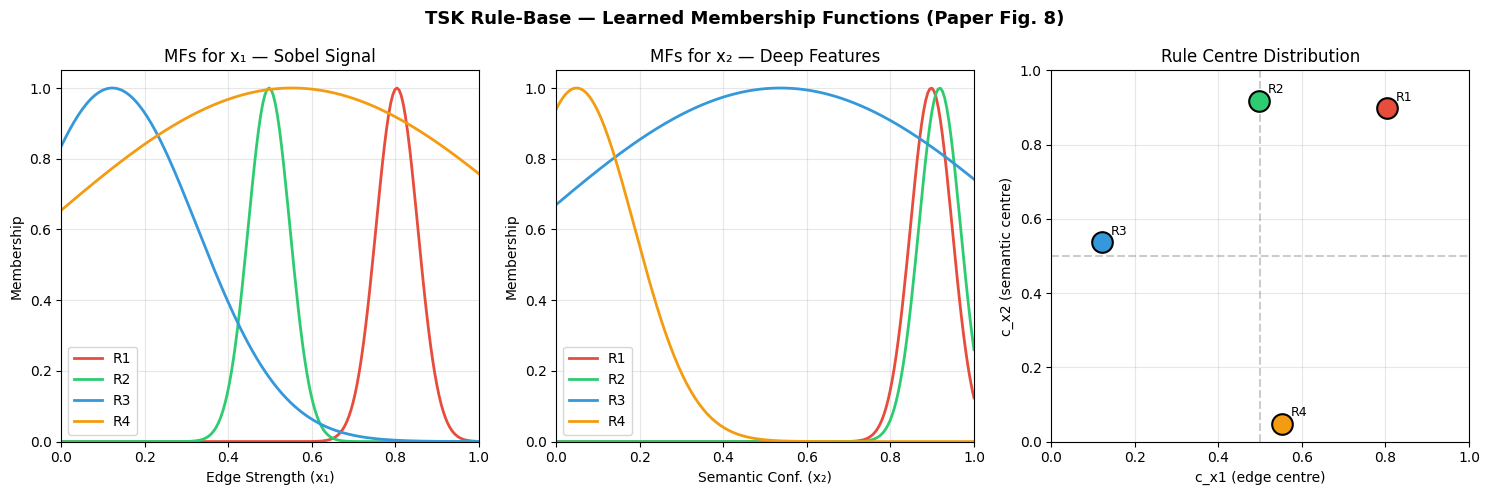

TSK rule visualisation saved


In [25]:
x_range  = np.linspace(0, 1, 200)
tsk_head = model.tsk_head

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TSK Rule-Base — Learned Membership Functions (Paper Fig. 8)',
             fontsize=13, fontweight='bold')
colours = ['#e74c3c','#2ecc71','#3498db','#f39c12']

print(f'  {"Rule":<8} {"c_x1":>8} {"σ_x1":>8} {"c_x2":>8} {"σ_x2":>8} {"r":>8} {"p":>8} {"q":>8}')
print('  ' + '-'*72)

for i, rule in enumerate(tsk_head.rules):
    # NOTE: now reading .sigma_floored (bounded [SIGMA_FLOOR, SIGMA_CEILING])
    # instead of raw .sigma.abs() — this is what the forward pass actually uses,
    # so the printed/plotted MF now matches real model behaviour exactly.
    cx1 = rule.mf_x1.center.item(); sx1 = rule.mf_x1.sigma_floored.item()
    cx2 = rule.mf_x2.center.item(); sx2 = rule.mf_x2.sigma_floored.item()
    rv  = rule.r.item(); pv = rule.p.item(); qv = rule.q.item()
    m1  = np.exp(-((x_range-cx1)**2)/(2*sx1**2+1e-8))
    m2  = np.exp(-((x_range-cx2)**2)/(2*sx2**2+1e-8))
    axes[0].plot(x_range, m1, color=colours[i], lw=2, label=f'R{i+1}')
    axes[1].plot(x_range, m2, color=colours[i], lw=2, label=f'R{i+1}')
    axes[2].scatter(cx1, cx2, s=220, color=colours[i], edgecolors='k', lw=1.5, zorder=5)
    axes[2].annotate(f'R{i+1}', (cx1+0.02, cx2+0.02), fontsize=9)
    print(f'  Rule {i+1:<4} {cx1:>8.3f} {sx1:>8.3f} {cx2:>8.3f} {sx2:>8.3f} {rv:>8.3f} {pv:>8.3f} {qv:>8.3f}')

for ax, xl, title in [(axes[0],'Edge Strength (x₁)','MFs for x₁ — Sobel Signal'),
                       (axes[1],'Semantic Conf. (x₂)','MFs for x₂ — Deep Features')]:
    ax.set(xlabel=xl, ylabel='Membership', title=title, xlim=[0,1], ylim=[0,1.05])
    ax.legend(); ax.grid(alpha=0.3)

axes[2].axhline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].axvline(0.5, color='gray', ls='--', alpha=0.4)
axes[2].set(xlabel='c_x1 (edge centre)', ylabel='c_x2 (semantic centre)',
            title='Rule Centre Distribution', xlim=[0,1], ylim=[0,1])
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{WORK_DIR}/tsk_rule_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('TSK rule visualisation saved')